In [2]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

In [3]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [4]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/job_array/'
with h5py.File(dir2+'lagrangian_binary_array.h5', 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [5]:
#job array setup #UNCOMMENT IF USING JOB_ARRAY
num_jobs=60 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***
job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
if job_id==0: job_id=30
    
num_parcels=len(data['time']) #total num of variables
job_range = num_parcels//num_jobs #number of parcels per job 
start_job = (job_id - 1) * job_range
end_job = start_job + job_range
if job_id==num_jobs: end_job=num_parcels-1


#FOR ENTRAINMENT THE PREVIOUS TIMESTEP IS ALWAYS NEEDED, SO SLICED WILL CAUSE WRAP AROUND DATA
#INSTEAD NP.WHERE RESULTS MUST BE SUBSETTED
# data=data.isel(time=slice(start_job,end_job))
# parcel=parcel.isel(time=slice(start_job,end_job))

# #SLICING LAGRANGIAN BINARY ARRAY
# A_g=A_g[slice(start_job,end_job)]
# A_c=A_c[slice(start_job,end_job)]
# Z=Z[slice(start_job,end_job)]
# Y=Y[slice(start_job,end_job)]
# X=X[slice(start_job,end_job)]

In [ ]:
###########################################################################################################################################################################

In [ ]:
#ENTRAINMENT/DETRAINMENT
########################################################################################################

In [19]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=data['xf'][-1].item()-data['xf'][0].item() #x length (km)
Ly=data['yf'][-1].item()-data['yf'][0].item() #y length (km)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len('zh')):
        for j in range(len('yh')):
            for i in range(len('xh')):
                rho_out=rho(i,j,k,t)
                m+=rho_out*(zf(k+1)-zf(k))
    #triple sum
    m=m*dx*dy/Np
    out=m
    return out

In [20]:
def ed(A,z,t,type):
    #Get Z Locations
    zs=Z[t,:]
    
    #Essential A_t-A_(t-1)
    D=A[t,:]-A[t-1,:]
    
    #Essentially the I function
    z_ind=np.where(zs==z)
    A_z=D[z_ind]
    
    #Esentially the H function

    if type=='e':
        A_z[A_z<0]=0 #entrainment
    if type=='d':
        A_z[A_z>0]=0 #detrainment

    #Essentially the sumnation
    A_sum=np.sum(A_z)

    if type=='d': 
        A_sum*=-1

    #CONSTANT
    ############
    m_out=m(t)
    dz=zf(z+1)-zf(z)
    constant=(m_out/Lx/Ly/dz/dt) 
    # constant=1
    A_sum*=constant
    return A_sum

#creates 2d storage array
tlen=len(data['time'])
zlen=len(data['zh'])
profile_array_e_g=np.zeros((tlen,zlen))
profile_array_d_g=np.zeros((tlen,zlen))
profile_array_e_c=np.zeros((tlen,zlen))
profile_array_d_c=np.zeros((tlen,zlen))

#Adding to Profile Array
import itertools
ts = range(0, 141)  # ts from 0 to 140
zs = range(0, 34)   # zs from 0 to 34
for count, (t, z) in enumerate(itertools.product(ts, zs)):
    if np.mod(count,10000)==0: print(f'{count*100/len(ts):.2f}%')

    #GENERAL
    A_sum_g=ed(A_g, z,t,type='e')
    profile_array_e_g[t,z]+=A_sum_g
    A_sum_g=ed(A_g, z,t,type='d')
    profile_array_d_g[t,z]+=A_sum_g

    #CLOUDY
    A_sum_c=ed(A_c, z,t,type='e')
    profile_array_e_c[t,z]+=A_sum_c
    A_sum_c=ed(A_c, z,t,type='d')
    profile_array_d_c[t,z]+=A_sum_c

#SAVING
dir3=dir+'Project_Algorithms/Entrainment/2D_entrainment_profiles.h5'
with h5py.File(dir3, "w") as h5f:
    h5f.create_dataset("profile_array_e_g", data=profile_array_e_g)
    h5f.create_dataset("profile_array_e_c", data=profile_array_e_c)
    h5f.create_dataset("profile_array_d_g", data=profile_array_d_g)
    h5f.create_dataset("profile_array_d_c", data=profile_array_d_c)

0.00%


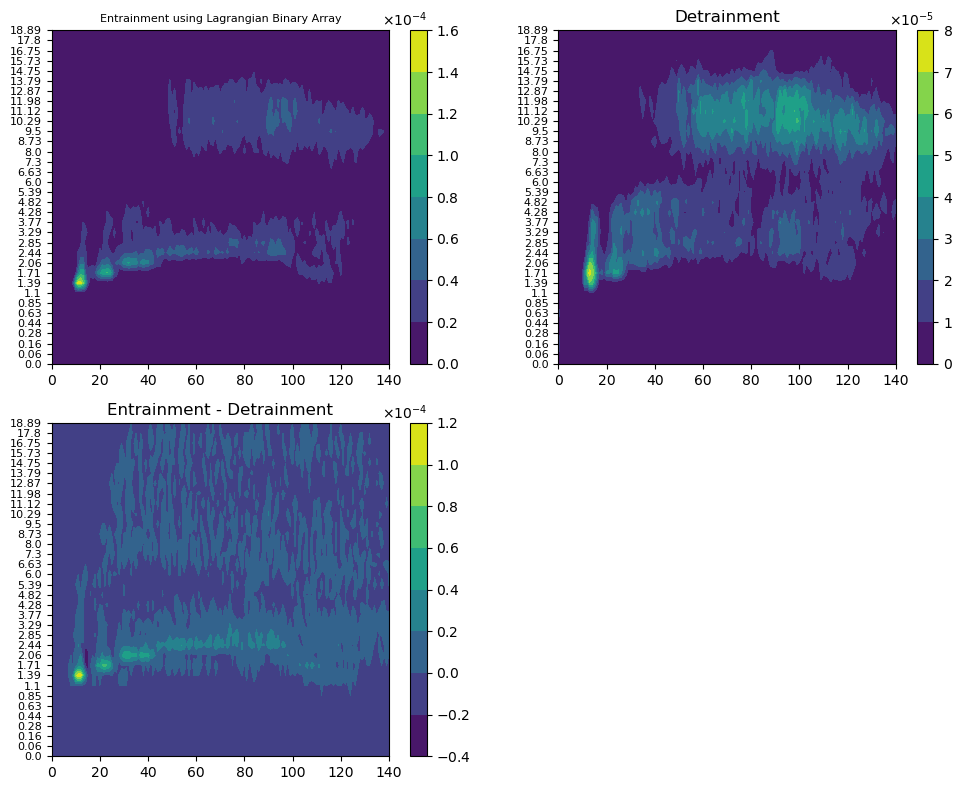

In [36]:
# type='general'
type='cloudy'

with h5py.File(dir3, "r") as h5f:
    profile_array_e_g = h5f["profile_array_e_g"][:]
    profile_array_e_c = h5f["profile_array_e_c"][:]
    profile_array_d_g = h5f["profile_array_d_g"][:]
    profile_array_d_c = h5f["profile_array_d_c"][:]

if type=='general':
    profile_array_e=profile_array_e_g
    profile_array_d=profile_array_d_g
if type=='cloudy':
    profile_array_e=profile_array_e_c
    profile_array_d=profile_array_d_c


import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig)

# First subplot: Entrainment
ax1 = fig.add_subplot(gs[0, 0])
contour1 = ax1.contourf(profile_array_e.T)
cbar1=fig.colorbar(contour1, ax=ax1)
Nz = len(data['zh'])
ax1.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax1.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax1.set_title('Entrainment using Lagrangian Binary Array',fontsize=8)

# Second subplot: Detainment
ax2 = fig.add_subplot(gs[0, 1])
contour2 = ax2.contourf(profile_array_d.T)
cbar2 = fig.colorbar(contour2, ax=ax2)
ax2.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax2.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax2.set_title('Detrainment')

# Second subplot: Detainment
ax3 = fig.add_subplot(gs[1, 0])
contour3 = ax3.contourf((profile_array_e-profile_array_d).T)
cbar3=fig.colorbar(contour3, ax=ax3)
ax3.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax3.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax3.set_title('Entrainment - Detrainment')

# Display the plot
plt.tight_layout()




from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))  # Adjust the range for scientific notation
for cbar in (cbar1,cbar2, cbar3):  # These must be Colorbar instances
    cbar.formatter = formatter
    cbar.update_ticks()

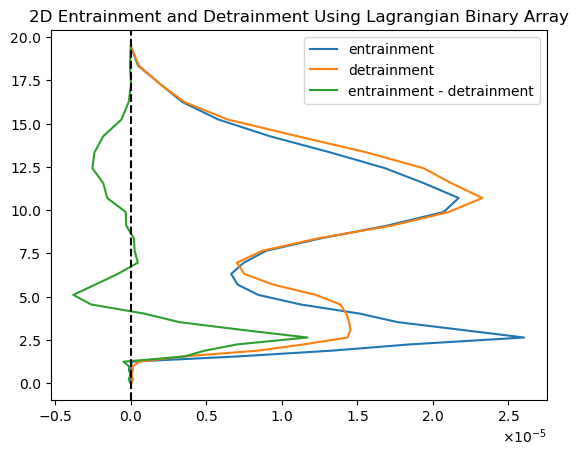

In [37]:
plt.plot(np.mean(profile_array_e,axis=(0)),data['zh'],label='entrainment')
plt.plot(np.mean(profile_array_d,axis=(0)),data['zh'],label='detrainment')
plt.plot(np.mean(profile_array_e-profile_array_d,axis=0),data['zh'],label='entrainment - detrainment')
plt.axvline(0,color='k',linestyle='dashed')

plt.legend(); plt.title('2D Entrainment and Detrainment Using Lagrangian Binary Array')

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
plt.gca().xaxis.set_major_formatter(formatter)

In [21]:
############## 3D ENTRAINMENT

In [6]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=data['xf'][-1].item()-data['xf'][0].item() #x length (km)
Ly=data['yf'][-1].item()-data['yf'][0].item() #y length (km)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len('zh')):
        for j in range(len('yh')):
            for i in range(len('xh')):
                rho_out=rho(i,j,k,t)
                m+=rho_out*(zf(k+1)-zf(k))
    #triple sum
    m=m*dx*dy/Np
    out=m
    return out

In [27]:
def ed3d(A,t,z,y,x,type):
    #Get Z Locations
    zs=Z[t,:]
    ys=Y[t,:]
    xs=X[t,:]
    
    #Essential A_t-A_(t-1)
    D=A[t,:]-A[t-1,:]
    
    #Essentially the I function
    zyx_ind=np.where((zs==z)&(ys==y)&(xs==x))
    A_z=D[zyx_ind]
    
    #Esentially the H function

    if type=='e':
        A_z[A_z<0]=0 #entrainment
    if type=='d':
        A_z[A_z>0]=0 #detrainment

    #Essentially the sumnation
    A_sum=np.sum(A_z)

    # if type=='d': 
    #     A_sum*=-1

    #CONSTANT
    ############
    m_out=m(t)
    dz=zf(z+1)-zf(z);dy=1000;dx=1000
    constant=(m_out/dx/dy/dz/dt) 
    # constant=1
    A_sum*=constant
    return A_sum

In [8]:
#LOADING VARIABLES
if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    # variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data

    print('done loading')
    emptylike=True

loading neccessary variables
done loading


In [43]:
#JOB ARRAY FOR SUBSETTING NP.WHERE OUTPUTS
def job_subset_where_e(where):
    array1, array2, array3, array4 = where
    mask = (array1 >= start_job) & (array1 < end_job)
    filtered_data = tuple(arr[mask] for arr in where) #USE IN INITIALIZING FULL ARRAY EACH TIME
    return filtered_data

def job_subset_where_d(where):
    array1, array2, array3, array4 = where
    array1+=1
    mask = (array1 >= start_job) & (array1 < end_job)
    filtered_data = tuple(arr[mask] for arr in where) #USE IN INITIALIZING FULL ARRAY EACH TIME
    return filtered_data

In [65]:
#SET UP TO RUN WITH JOB_ARRAY

#creates 2d storage array

# tlen=len(data['time'])
tlen=end_job-start_job
zlen=len(data['zh'])
ylen=len(data['yh'])
xlen=len(data['xh'])

profile_array_e_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_e_c=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_c=np.zeros((tlen,zlen,ylen,xlen))
    
#Adding to Profile Array
# import itertools
# ts = range(0, 141)  # ts from 0 to 140
# zs = range(0, 34)   # zs from 0 to 34
# for count, (t, z) in enumerate(itertools.product(ts, zs)):

#GENERAL UPDRAFTS
w_thresh1=0.1
indices=np.where((w_data>=w_thresh1))

#ENTRAINMENT
indices_e=job_subset_where_e(indices) #USE FOR JOB_ARRAY ONLY***
if np.any(indices_e)==True:
    tmin=np.min(indices_e[0]) #USE FOR JOB_ARRAY ONLY***
else: 
    tmin=0
for count, (t, z, y, x) in enumerate(zip(*indices_e)):
    if np.mod(count,10000)==0: print(f'{count*100/len(indices_e[0]):.2f}%')
    
    A_sum_e_g=ed3d(A_g,t,z,y,x,type='e')
    # profile_array_e_g[t,z,y,x]+=A_sum_e_g
    profile_array_e_g[t-tmin,z,y,x]+=A_sum_e_g

#DETRAINMENT
indices_d=job_subset_where_d(indices) #USE FOR JOB_ARRAY ONLY***
if np.any(indices_d)==True:
    tmin=np.min(indices_d[0]) #USE FOR JOB_ARRAY ONLY***
else: 
    tmin=0
for count, (t, z, y, x) in enumerate(zip(*indices_d)):
    if np.mod(count,10000)==0: print(f'{count*100/len(indices_d[0]):.2f}%')
    
    A_sum_d_g=ed3d(A_g,t,z,y,x,type='d')
    # profile_array_d_g[t,z,y,x]+=A_sum_d_g
    profile_array_d_g[t-tmin,z,y,x]+=A_sum_d_g


#CLOUDY UPDRAFTS
w_thresh2=0.5
qcqi_thresh=1e-6
indices=np.where((w_data>=w_thresh2)&(qc_plus_qi>=qcqi_thresh))

#ENTRAINMENT
indices_e=job_subset_where_e(indices) #USE FOR JOB_ARRAY ONLY***
if np.any(indices_e)==True:
    tmin=np.min(indices_e[0]) #USE FOR JOB_ARRAY ONLY***
else: 
    tmin=0
for count, (t, z, y, x) in enumerate(zip(*indices_e)):
    if np.mod(count,10000)==0: print(f'{count*100/len(indices_e[0]):.2f}%')
        
    A_sum_e_c=ed3d(A_c,t,z,y,x,type='e')
    # profile_array_e_c[t,z,y,x]+=A_sum_e_c
    profile_array_e_c[t-tmin,z,y,x]+=A_sum_e_c


#DETRAINMENT
indices_d=job_subset_where_d(indices) #USE FOR JOB_ARRAY ONLY***
if np.any(indices_d)==True:
    tmin=np.min(indices_d[0]) #USE FOR JOB_ARRAY ONLY***
else: 
    tmin=0
for count, (t, z, y, x) in enumerate(zip(*indices_d)):
    if np.mod(count,10000)==0: print(f'{count*100/len(indices_d[0]):.2f}%')
    
    A_sum_d_c=ed3d(A_c,t,z,y,x,type='d')
    # profile_array_d_c[t,z,y,x]+=A_sum_d_c
    profile_array_d_c[t-tmin,z,y,x]+=A_sum_d_c


#SAVING
dir3=dir+f'Project_Algorithms/Entrainment/job_out/3D_entrainment_profiles{job_id}.h5'
with h5py.File(dir3, "w") as h5f:
    h5f.create_dataset("profile_array_e_g", data=profile_array_e_g)
    h5f.create_dataset("profile_array_e_c", data=profile_array_e_c)
    h5f.create_dataset("profile_array_d_g", data=profile_array_d_g)
    h5f.create_dataset("profile_array_d_c", data=profile_array_d_c)

0.00%


In [5]:
#######################################################
#COMBINING JOB_ARRAYS (RUN AFTER ALL JOB_ARRAYS ARE FINISHED)

tlen=len(netCDF['time'])
zlen=len(netCDF['zh'])
ylen=len(netCDF['yh'])
xlen=len(netCDF['xh'])
profile_array_e_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_e_c=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_c=np.zeros((tlen,zlen,ylen,xlen))

tlen1=0
for job_id in np.arange(1,30+1):
    dir3=dir+f'Project_Algorithms/Entrainment/job_out/3D_entrainment_profiles{job_id}.h5'
    with h5py.File(dir3, "r") as h5f:
        tlen2=tlen1+h5f["profile_array_e_g"][:].shape[0]
        print(tlen1,tlen2)

        profile_array_e_g[tlen1:tlen2] = h5f["profile_array_e_g"][:]
        profile_array_e_c[tlen1:tlen2] = h5f["profile_array_e_c"][:]
        profile_array_d_g[tlen1:tlen2] = h5f["profile_array_d_g"][:]
        profile_array_d_c[tlen1:tlen2] = h5f["profile_array_d_c"][:]

        tlen1=tlen2

#SAVING
dir3=dir+f'Project_Algorithms/Entrainment/3D_entrainment_profiles.h5'
with h5py.File(dir3, "w") as h5f:
    h5f.create_dataset("profile_array_e_g", data=profile_array_e_g)
    h5f.create_dataset("profile_array_e_c", data=profile_array_e_c)
    h5f.create_dataset("profile_array_d_g", data=profile_array_d_g)
    h5f.create_dataset("profile_array_d_c", data=profile_array_d_c)

0 4
4 8
8 12
12 16
16 20
20 24
24 28
28 32
32 36
36 40
40 44
44 48
48 52
52 56
56 60
60 64
64 68
68 72
72 76
76 80
80 84
84 88
88 92
92 96
96 100
100 104
104 108
108 112
112 116
116 140


In [22]:
#######################################################
#READING BACK IN 
dir3=dir+'Project_Algorithms/Entrainment/3D_entrainment_profiles.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_e_g = h5f["profile_array_e_g"][:]
    profile_array_e_c = h5f["profile_array_e_c"][:]
    profile_array_d_g = h5f["profile_array_d_g"][:]
    profile_array_d_c = h5f["profile_array_d_c"][:]

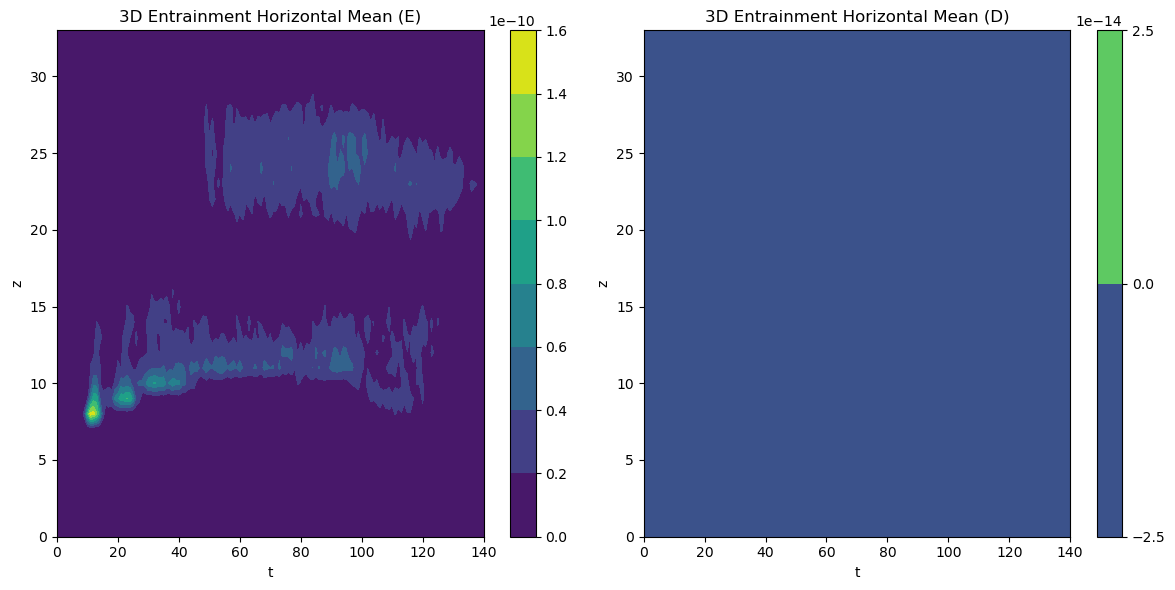

In [26]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(12, 6))
gs = GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
# out = np.sum(profile_array_e_c, axis=(2, 3))
out = np.mean(profile_array_e_c, axis=(2, 3))
cf1 = ax1.contourf(out.T, cmap='viridis')
fig.colorbar(cf1, ax=ax1, orientation='vertical')
ax1.set_title('3D Entrainment Horizontal Mean (E)')
ax1.set_xlabel('t')
ax1.set_ylabel('z')

ax2 = fig.add_subplot(gs[0, 1])
# out = np.sum(profile_array_d_c, axis=(2, 3))
out = np.mean(profile_array_d_c, axis=(2, 3))
cf2 = ax2.contourf(out.T, cmap='viridis')
fig.colorbar(cf2, ax=ax2, orientation='vertical')
ax2.set_title('3D Entrainment Horizontal Mean (D)')
ax2.set_xlabel('t')
ax2.set_ylabel('z')

plt.tight_layout()

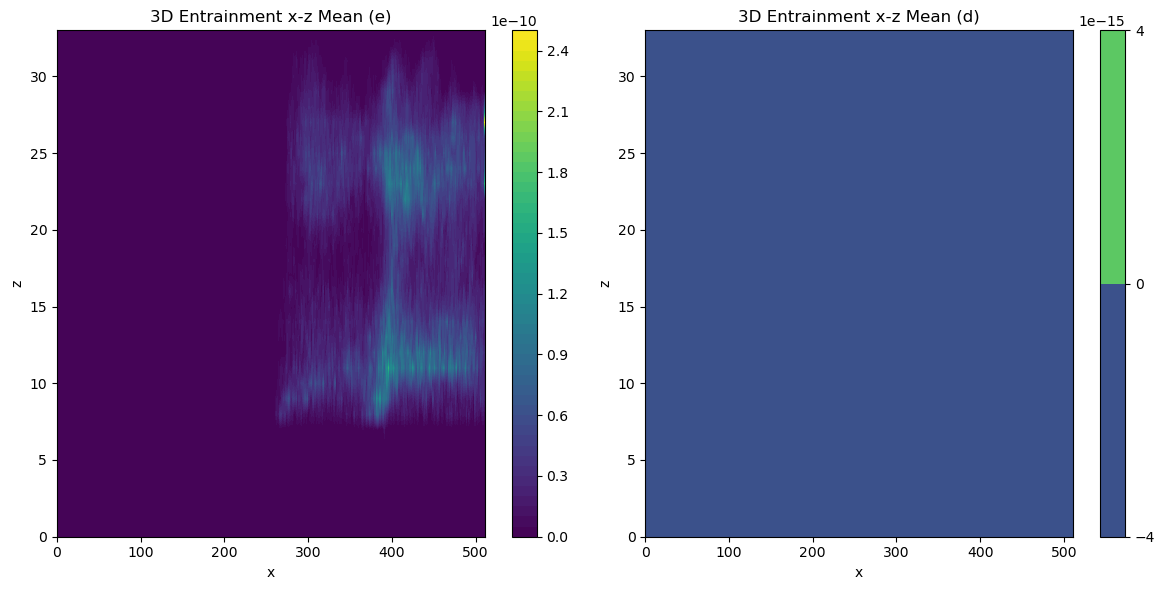

In [25]:
fig = plt.figure(figsize=(12, 6))
gs = GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
# out = np.sum(profile_array_e_c, axis=(0, 2))
out = np.mean(profile_array_e_c, axis=(0, 2))
cf1 = ax1.contourf(out, levels=50, cmap='viridis')
fig.colorbar(cf1, ax=ax1, orientation='vertical')
ax1.set_title('3D Entrainment x-z Mean (e)')
ax1.set_xlabel('x')
ax1.set_ylabel('z')

ax2 = fig.add_subplot(gs[0, 1])
# out = np.sum(profile_array_d_c, axis=(0, 2))
out = np.mean(profile_array_d_c, axis=(0, 2))
cf2 = ax2.contourf(out, levels=50, cmap='viridis')
fig.colorbar(cf2, ax=ax2, orientation='vertical')
ax2.set_title('3D Entrainment x-z Mean (d)')
ax2.set_xlabel('x')
ax2.set_ylabel('z')

plt.tight_layout()

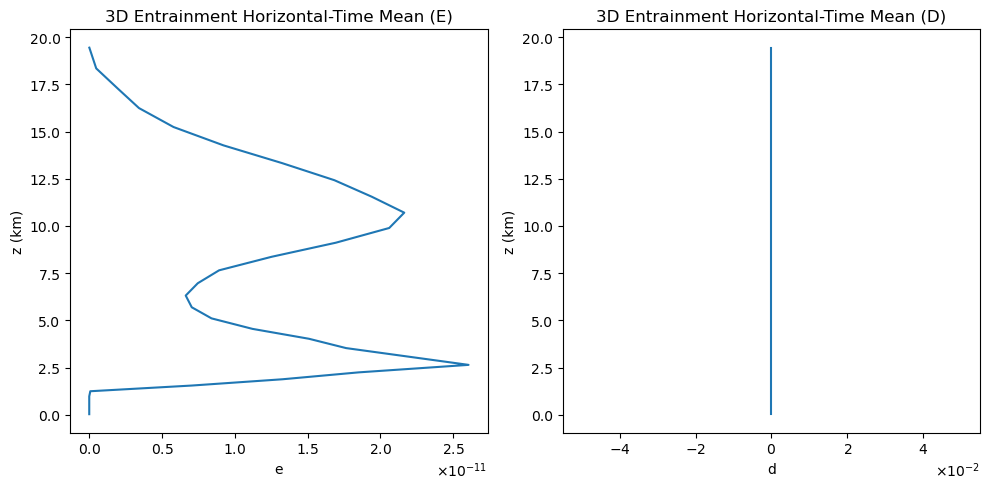

In [18]:
from matplotlib.gridspec import GridSpec
                          
fig = plt.figure(figsize=(10, 5))
gs = GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
# out = np.sum(profile_array_e_c, axis=(0, 2, 3))
out = np.mean(profile_array_e_c, axis=(0, 2, 3))
ax1.plot(out, data['zh'])
ax1.set_title('3D Entrainment Horizontal-Time Mean (E)')
ax1.set_xlabel('e')
ax1.set_ylabel('z (km)')

ax2 = fig.add_subplot(gs[0, 1])
# out = np.sum(profile_array_d_c, axis=(0, 2, 3))
out = np.mean(profile_array_d_c, axis=(0, 2, 3))
ax2.plot(out, data['zh'])
ax2.set_title('3D Entrainment Horizontal-Time Mean (D)')
ax2.set_xlabel('d')
ax2.set_ylabel('z (km)')

apply_scientific_notation([ax1,ax2])
plt.tight_layout() #SOMETHING IS OFF WITH DETRAINMENT******


In [115]:
# #PLOTTING W VS ENTRAINMENT

# if 'emptylike' not in globals():
#     print('loading neccessary variables')
#     variable='w'; w_data=data[variable] #get w data
#     w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
#     variable='qv'; qv_data=data[variable].data # get qc data
#     variable='qc'; qc_data=data[variable].data # get qc data
#     variable='qi'; qi_data=data[variable].data # get qc data
#     qc_plus_qi=qc_data+qi_data

#     print('done loading')
#     emptylike=True
    
# def final_profile(var,type):
#     global w_thresh
#     #thresholds
#     w_thresh=1; w_thresh=0.5 #TESTING***
#     qcqithresh=1e-6; qcqithresh=1e-9 #TESTING***

#     nt=len(data['time'])
        
#     #get qc and interpolated w 

#     # finds regions that match the threshold
#     if type=="general":
#         where_updraft=np.where((w_data>=w_thresh)) #uncomment for "general updraft"
#     elif type=='cloudy': 
#         where_updraft=np.where((w_data>=w_thresh) & (qc_plus_qi>=qcqithresh)) #uncomment for "cloudy updraft" 
    
#     #creates profile storage and adds z column    
#     zhs=data['zh'].values
#     profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
#     profile_array[:,2]=zhs

#     #get incidies associated with threshold mask
#     t_ind, z_ind, y_ind, x_ind = where_updraft

#     #gets data associated with threshold mask
#     if var=='w':
#         masked_data=w_data[where_updraft]
#     if var=='qv':
#         masked_data=qv_data[where_updraft]
#     if var=='qc':
#         # masked_data=qc_plus_qi[where_updraft] #data stored for qc is actually qc+qi
#         masked_data=qc_data[where_updraft] #data stored for qc is actually qc+qi
#     if var=='qi':
#         masked_data=qi_data[where_updraft]
#     if var=='th':
#         masked_data=th_data[where_updraft]
#     if var=='th_e':
#         masked_data=theta_e_data[where_updraft]
#     if var=='buoyancy':
#         masked_data=buoyancy_data[where_updraft]
#     # if var=='pgrad':
#     #     pgrad_data=data['wb_pgrad'].interp(zf=data['zh']).data
#     #     masked_data=pgrad_data[where_updraft]
        
#     #converts qv and qc from kg/kg=>g/kg
#     if var in ['qv','qc','qi']:
#         masked_data*=1000

#     #bin masked values by z level
#     for (kh,value) in zip(z_ind,masked_data):
#         profile_array[kh,0]+=value #adds data to first column
#         profile_array[kh,1]+=1 #adds +1 counter to 2nd column
#     return profile_array

In [253]:
# # w_data=data['w'].interp(zf=data['zh']).data
# w_thresh=0; w_thresh=0.5 #m/s
# qcqi_thresh=1e-6; qcqi_thresh=1e-9 #kg/kg
# w_profile=final_profile('w',type='cloudy')

# def averaged_profiles(profile):
#     out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
#     out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
#     return out_var
# w_profile_avg=averaged_profiles(w_profile)

In [254]:
# qv_profile=final_profile('qv',type='cloudy')

# def averaged_profiles(profile):
#     out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
#     out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
#     return out_var
# qv_profile_avg=averaged_profiles(qv_profile)

In [302]:
# import matplotlib.pyplot as plt
# import numpy as np
# from matplotlib import gridspec

# ws = w_profile_avg[:, 0]  # Example: w profile
# qvs = qv_profile_avg[:, 0]  # Example: w profile
# out=np.mean(profile_array_e,axis=(0,2,3))
# es = out  # Example: entrainment data

# # Create a figure and GridSpec
# fig = plt.figure(figsize=(14, 6))
# gs = gridspec.GridSpec(2, 2, figure=fig)

# # Create subplots using GridSpec
# ax1 = plt.subplot(gs[0,0])  
# ax2 = plt.subplot(gs[0,1]) 

# # Plot on ax1 (scatter plot with line)
# ax1.plot(ws, es, label='Entrainment vs W', color='blue')
# ax1.scatter(ws, es, color='red')
# ax1.set_xlabel('w (m/s)')
# ax1.set_ylabel('e')
# ax1.set_title('Entrainment vs W')
# ax1.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax2.set_aspect('auto')

# # Set labels and title for ax2
# ax2.set_xlabel('w (m/s)')
# ax2.set_ylabel('e')
# ax2.set_title('2D Histogram of W vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# # ##############################

# # Create subplots using GridSpec
# ax3 = plt.subplot(gs[1,0])  # Left subplot
# ax4 = plt.subplot(gs[1,1])  # Right subplot

# # Plot on ax1 (scatter plot with line)
# ax3.plot(qvs, es, label='Entrainment vs W', color='blue')
# ax3.scatter(qvs, es, color='red')
# ax3.set_xlabel(r'$q_v$ (g/kg)')
# ax1.set_ylabel('e')
# ax3.set_title('Entrainment vs QV')
# ax3.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax4.set_aspect('auto')

# # Set labels and title for ax2
# ax4.set_xlabel(r'$q_v$ (g/kg)')
# ax4.set_ylabel('e')
# ax4.set_title('2D Histogram of QV vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

# plt.suptitle('Vertical Profiles')
# plt.tight_layout()



In [39]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


out=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 
###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder=out_nz.copy(); run=True
############################################################
print(f'there are a total of {len(out_nz)} CL parcels and {len(save_nz)} nonCL parcels')


ALL_out_nz=out_nz.copy(); ALL_save_nz=save_nz.copy()

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
there are a total of 2088 CL parcels and 1717 nonCL parcels


In [40]:
#SHALLOW

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def SHALLOW_threshold(zthresh,type):

    if type=='CL':
        out_nz=ALL_out_nz.copy()
    if type=='nonCL':
        out_nz=ALL_save_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################

convectivelevel=4 #4km
SHALLOW_out_nz=SHALLOW_threshold(convectivelevel,type='CL')
SHALLOW_save_nz=SHALLOW_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(SHALLOW_out_nz)} CL parcels and {len(SHALLOW_save_nz)} nonCL parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
there are a total of 1152 CL parcels and 1048 nonCL parcels


In [41]:
#DEEP

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def DEEP_threshold(zthresh,type):
    if type=='CL':
        out_nz=ALL_out_nz.copy()
    if type=='nonCL':
        out_nz=ALL_save_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################

convectivelevel=6 #4km
DEEP_out_nz=DEEP_threshold(convectivelevel,type='CL')
DEEP_save_nz=DEEP_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(DEEP_out_nz)} CL parcels and {len(DEEP_save_nz)} nonCL parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
there are a total of 374 CL parcels and 314 nonCL parcels


In [383]:
#GET 3D Entrainment Array ***
dir3=dir+'Project_Algorithms/Entrainment/3D_entrainment_profiles.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_e_g = h5f["profile_array_e_g"][:]
    profile_array_e_c = h5f["profile_array_e_c"][:]
    profile_array_d_g = h5f["profile_array_d_g"][:]
    profile_array_d_c = h5f["profile_array_d_c"][:]

In [354]:
#ALL
def data_collect(out_nz,type):
    if type=='above_below':
        #Above and Below LFC
        
        ws=[];qvs=[]; es=[]
        zs_lst=[]
        
        nummins=20; numsteps=int(nummins/times[1])
        
        for ind in np.arange(out_nz.shape[0]):
            row=out_nz[ind]
            ts=np.arange(row[4],row[5]+numsteps+1)
            p=row[0]
            zs=Z[ts,p];ys=Y[ts,p];xs=X[ts,p]
            
            w_row=w_data[ts,zs,ys,xs]; ws.extend(w_row)
            qv_row=qv_data[ts,zs,ys,xs]; qvs.extend(qv_row)
            e_row=profile_array_e[ts,zs,ys,xs]; es.extend(e_row) #USING PRECALCULATED 3D ENTRAINMENT ARRAY

            zs_lst.extend(zs)
    if type=='below':
        #Below LFC
        zhs=data['zh'].values*1000 #TESTING
        lfc_data=data['lfc'].data #TESTING
        
        ws=[];qvs=[]; es=[]
        zs_lst=[]
        
        nummins=20; numsteps=int(nummins/times[1])
        for ind in np.arange(out_nz.shape[0]):
            row=out_nz[ind]
            ts=np.arange(row[4],row[5]+numsteps+1)
            p=row[0]
            zs=Z[ts,p];ys=Y[ts,p];xs=X[ts,p]
        
            lfc_row=lfc_data[ts,ys,xs] #TESTING
            where=np.where(zhs[zs]<=lfc_row) #TESTING
        
            ts=ts[where];zs=zs[where];ys=ys[where];xs=xs[where]
            
            w_row=w_data[ts,zs,ys,xs]; ws.extend(w_row)
            qv_row=qv_data[ts,zs,ys,xs]; qvs.extend(qv_row)
            e_row=profile_array_e[ts,zs,ys,xs]; es.extend(e_row)

            zs_lst.extend(zs)
    if type=='above':
        #Above LFC
        zhs=data['zh'].values*1000 #TESTING
        lfc_data=data['lfc'].data #TESTING
        
        ws=[];qvs=[]; es=[]
        zs_lst=[]
        
        nummins=20; numsteps=int(nummins/times[1])
        for ind in np.arange(out_nz.shape[0]):
            row=out_nz[ind]
            ts=np.arange(row[4],row[5]+numsteps+1)
            p=row[0]
            zs=Z[ts,p];ys=Y[ts,p];xs=X[ts,p]
        
            lfc_row=lfc_data[ts,ys,xs] #TESTING
            where=np.where(zhs[zs]>=lfc_row) #TESTING
        
            ts=ts[where];zs=zs[where];ys=ys[where];xs=xs[where]
            
            w_row=w_data[ts,zs,ys,xs]; ws.extend(w_row)
            qv_row=qv_data[ts,zs,ys,xs]; qvs.extend(qv_row)
            e_row=profile_array_e[ts,zs,ys,xs]; es.extend(e_row)

            zs_lst.extend(zs)
    return ws,qvs,es,zs_lst

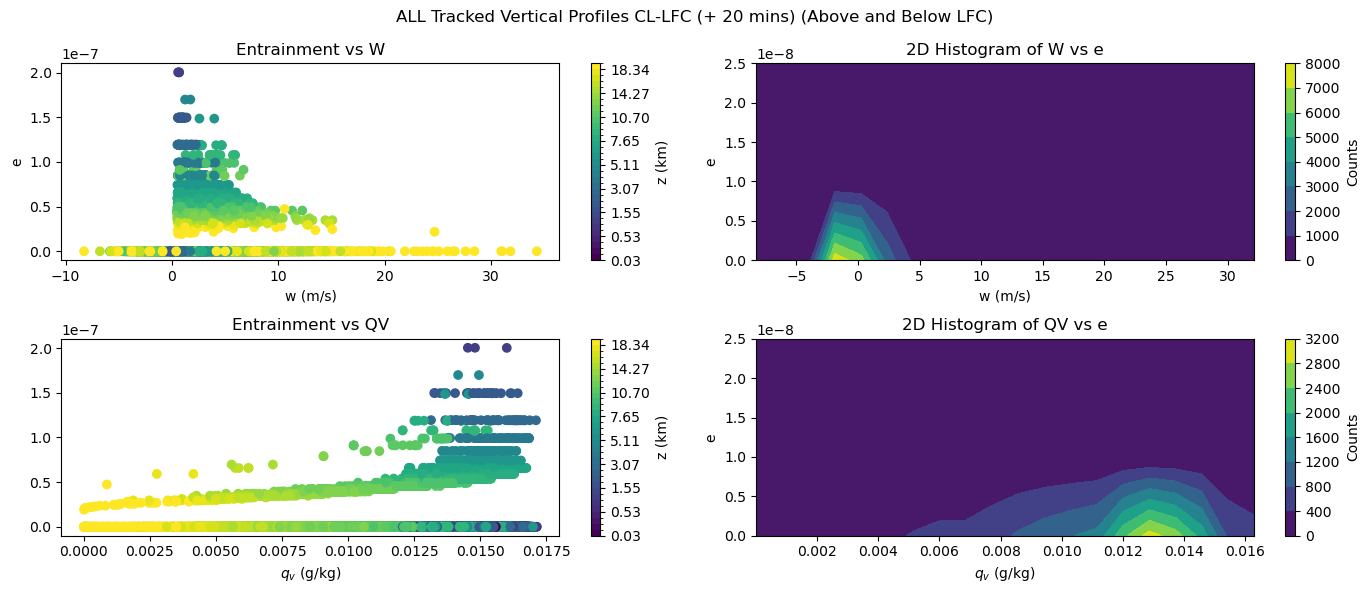

In [355]:
[ws,qvs,es,zs_lst]=data_collect(ALL_out_nz,type='above_below')


# Create a figure and GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
ax1 = plt.subplot(gs[0,0])  
ax2 = plt.subplot(gs[0,1]) 

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

# Labels
cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
ax1.set_xlabel('w (m/s)')
ax1.set_ylabel('e')
ax1.set_title('Entrainment vs W')
# ax1.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax2.set_aspect('auto')

# Set labels and title for ax2
ax2.set_ylim((0,0.25e-7))
ax2.set_xlabel('w (m/s)')
ax2.set_ylabel('e')
ax2.set_title('2D Histogram of W vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# ##############################

# Create subplots using GridSpec
ax3 = plt.subplot(gs[1,0])  # Left subplot
ax4 = plt.subplot(gs[1,1])  # Right subplot

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
ax3.set_xlabel(r'$q_v$ (g/kg)')
ax1.set_ylabel('e')
ax3.set_title('Entrainment vs QV')
# ax3.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax4.set_aspect('auto')

# Set labels and title for ax2
ax4.set_ylim((0,0.25e-7))
ax4.set_xlabel(r'$q_v$ (g/kg)')
ax4.set_ylabel('e')
ax4.set_title('2D Histogram of QV vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

plt.suptitle('ALL Tracked Vertical Profiles CL-LFC (+ 20 mins) (Above and Below LFC)')
plt.tight_layout()



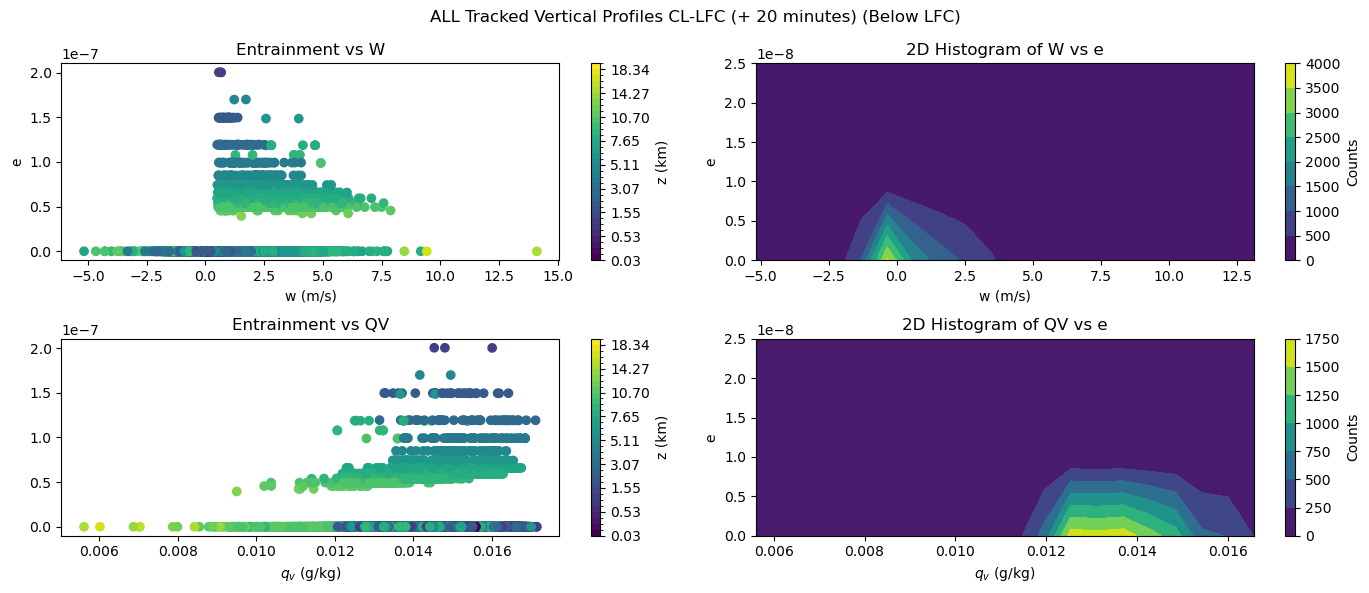

In [356]:
[ws,qvs,es,zs_lst]=data_collect(ALL_out_nz,type='below')

# Create a figure and GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
ax1 = plt.subplot(gs[0,0])  
ax2 = plt.subplot(gs[0,1]) 

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

# Labels
cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
ax1.set_xlabel('w (m/s)')
ax1.set_ylabel('e')
ax1.set_title('Entrainment vs W')
# ax1.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax2.set_aspect('auto')

# Set labels and title for ax2
ax2.set_ylim((0,0.25e-7))
ax2.set_xlabel('w (m/s)')
ax2.set_ylabel('e')
ax2.set_title('2D Histogram of W vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# ##############################

# Create subplots using GridSpec
ax3 = plt.subplot(gs[1,0])  # Left subplot
ax4 = plt.subplot(gs[1,1])  # Right subplot

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
ax3.set_xlabel(r'$q_v$ (g/kg)')
ax1.set_ylabel('e')
ax3.set_title('Entrainment vs QV')
# ax3.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax4.set_aspect('auto')

# Set labels and title for ax2
ax4.set_ylim((0,0.25e-7))
ax4.set_xlabel(r'$q_v$ (g/kg)')
ax4.set_ylabel('e')
ax4.set_title('2D Histogram of QV vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

plt.suptitle('ALL Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Below LFC)')
plt.tight_layout()



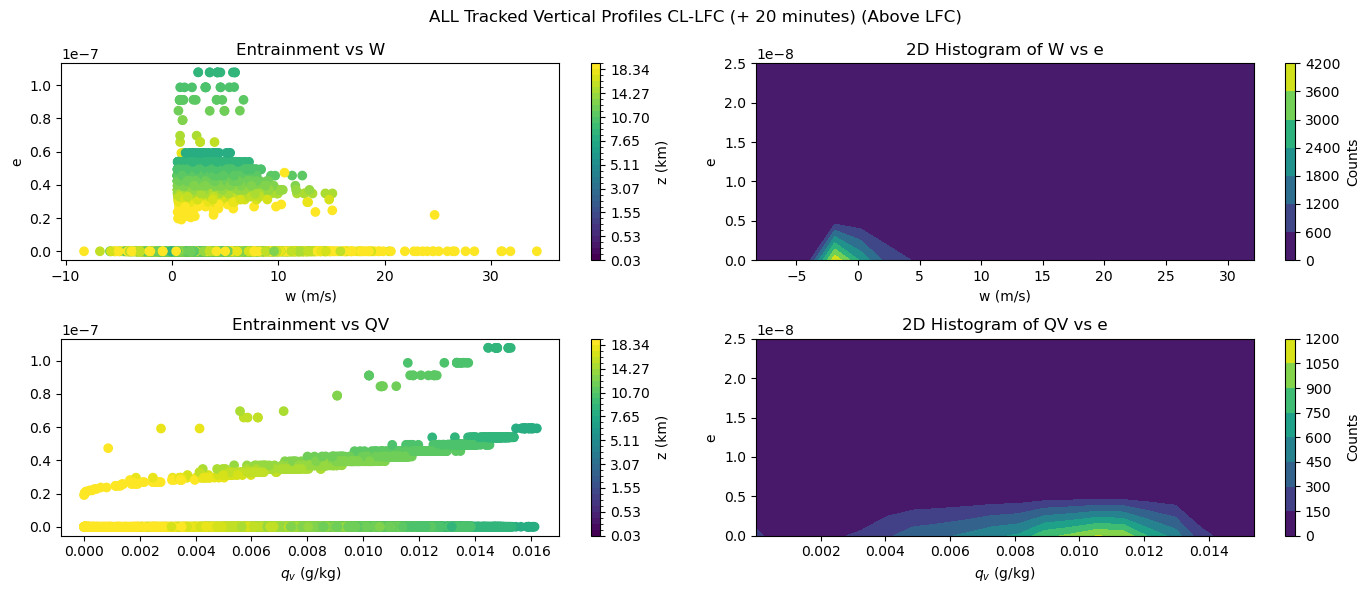

In [357]:
[ws,qvs,es,zs_lst]=data_collect(ALL_out_nz,type='above')

# Create a figure and GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
ax1 = plt.subplot(gs[0,0])  
ax2 = plt.subplot(gs[0,1]) 

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

# Labels
cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
ax1.set_xlabel('w (m/s)')
ax1.set_ylabel('e')
ax1.set_title('Entrainment vs W')
# ax1.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax2.set_aspect('auto')

# Set labels and title for ax2
ax2.set_ylim((0,0.25e-7))
ax2.set_xlabel('w (m/s)')
ax2.set_ylabel('e')
ax2.set_title('2D Histogram of W vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# ##############################

# Create subplots using GridSpec
ax3 = plt.subplot(gs[1,0])  # Left subplot
ax4 = plt.subplot(gs[1,1])  # Right subplot

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
ax3.set_xlabel(r'$q_v$ (g/kg)')
ax1.set_ylabel('e')
ax3.set_title('Entrainment vs QV')
# ax3.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax4.set_aspect('auto')

# Set labels and title for ax2
ax4.set_ylim((0,0.25e-7))
ax4.set_xlabel(r'$q_v$ (g/kg)')
ax4.set_ylabel('e')
ax4.set_title('2D Histogram of QV vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

plt.suptitle('ALL Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Above LFC)')
plt.tight_layout()



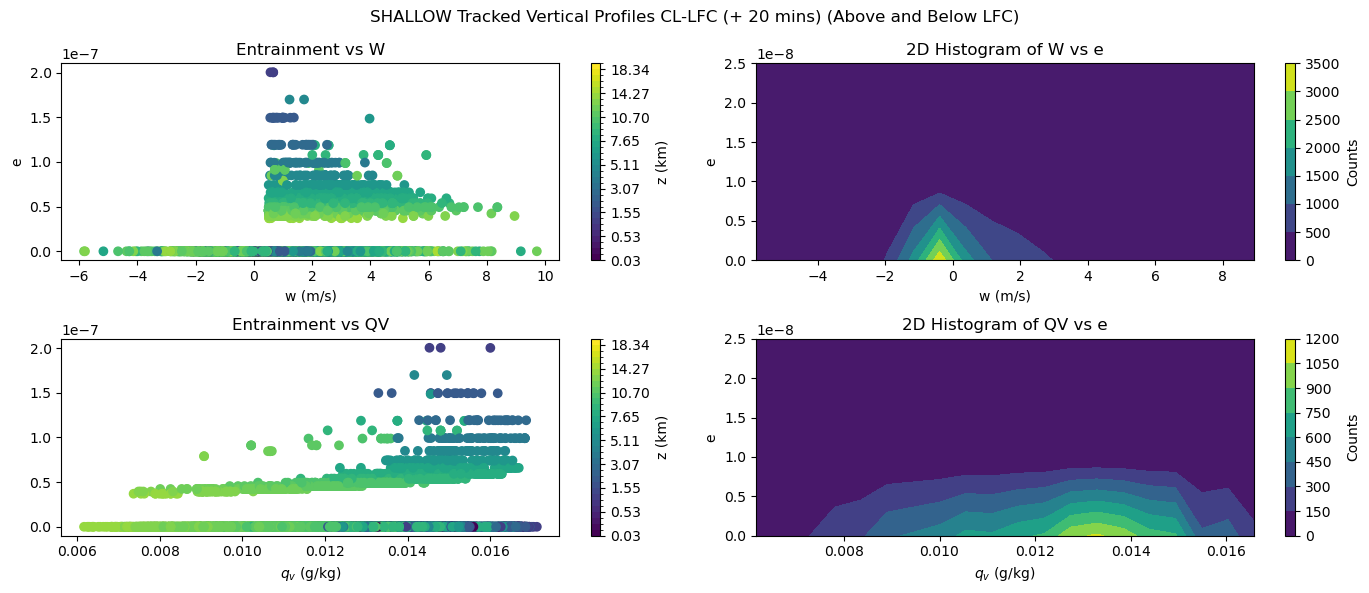

In [358]:
# SHALLOW
[ws,qvs,es,zs_lst]=data_collect(SHALLOW_out_nz,type='above_below')


# Create a figure and GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
ax1 = plt.subplot(gs[0,0])  
ax2 = plt.subplot(gs[0,1]) 

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

# Labels
cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
ax1.set_xlabel('w (m/s)')
ax1.set_ylabel('e')
ax1.set_title('Entrainment vs W')
# ax1.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax2.set_aspect('auto')

# Set labels and title for ax2
ax2.set_ylim((0,0.25e-7))
ax2.set_xlabel('w (m/s)')
ax2.set_ylabel('e')
ax2.set_title('2D Histogram of W vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# ##############################

# Create subplots using GridSpec
ax3 = plt.subplot(gs[1,0])  # Left subplot
ax4 = plt.subplot(gs[1,1])  # Right subplot

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
ax3.set_xlabel(r'$q_v$ (g/kg)')
ax1.set_ylabel('e')
ax3.set_title('Entrainment vs QV')
# ax3.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax4.set_aspect('auto')

# Set labels and title for ax2
ax4.set_ylim((0,0.25e-7))
ax4.set_xlabel(r'$q_v$ (g/kg)')
ax4.set_ylabel('e')
ax4.set_title('2D Histogram of QV vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

plt.suptitle('SHALLOW Tracked Vertical Profiles CL-LFC (+ 20 mins) (Above and Below LFC)')
plt.tight_layout()



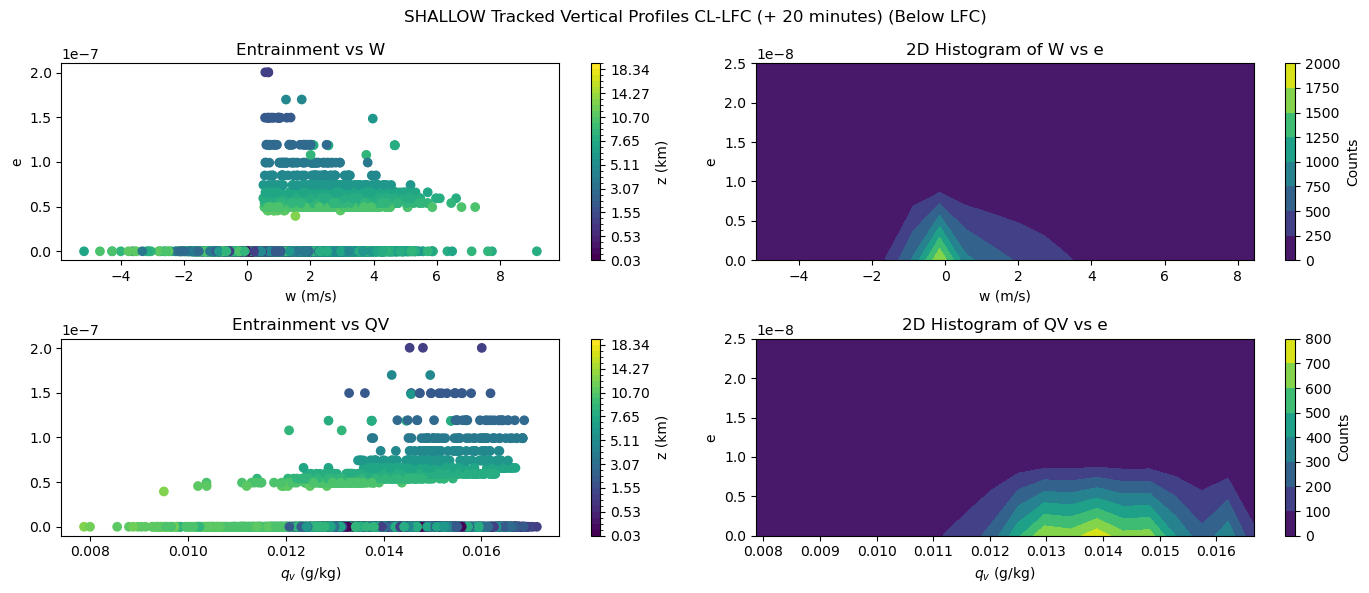

In [359]:
[ws,qvs,es,zs_lst]=data_collect(SHALLOW_out_nz,type='below')

# Create a figure and GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
ax1 = plt.subplot(gs[0,0])  
ax2 = plt.subplot(gs[0,1]) 

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

# Labels
cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
ax1.set_xlabel('w (m/s)')
ax1.set_ylabel('e')
ax1.set_title('Entrainment vs W')
# ax1.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax2.set_aspect('auto')

# Set labels and title for ax2
ax2.set_ylim((0,0.25e-7))
ax2.set_xlabel('w (m/s)')
ax2.set_ylabel('e')
ax2.set_title('2D Histogram of W vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# ##############################

# Create subplots using GridSpec
ax3 = plt.subplot(gs[1,0])  # Left subplot
ax4 = plt.subplot(gs[1,1])  # Right subplot

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
ax3.set_xlabel(r'$q_v$ (g/kg)')
ax1.set_ylabel('e')
ax3.set_title('Entrainment vs QV')
# ax3.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax4.set_aspect('auto')

# Set labels and title for ax2
ax4.set_ylim((0,0.25e-7))
ax4.set_xlabel(r'$q_v$ (g/kg)')
ax4.set_ylabel('e')
ax4.set_title('2D Histogram of QV vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

plt.suptitle('SHALLOW Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Below LFC)')
plt.tight_layout()



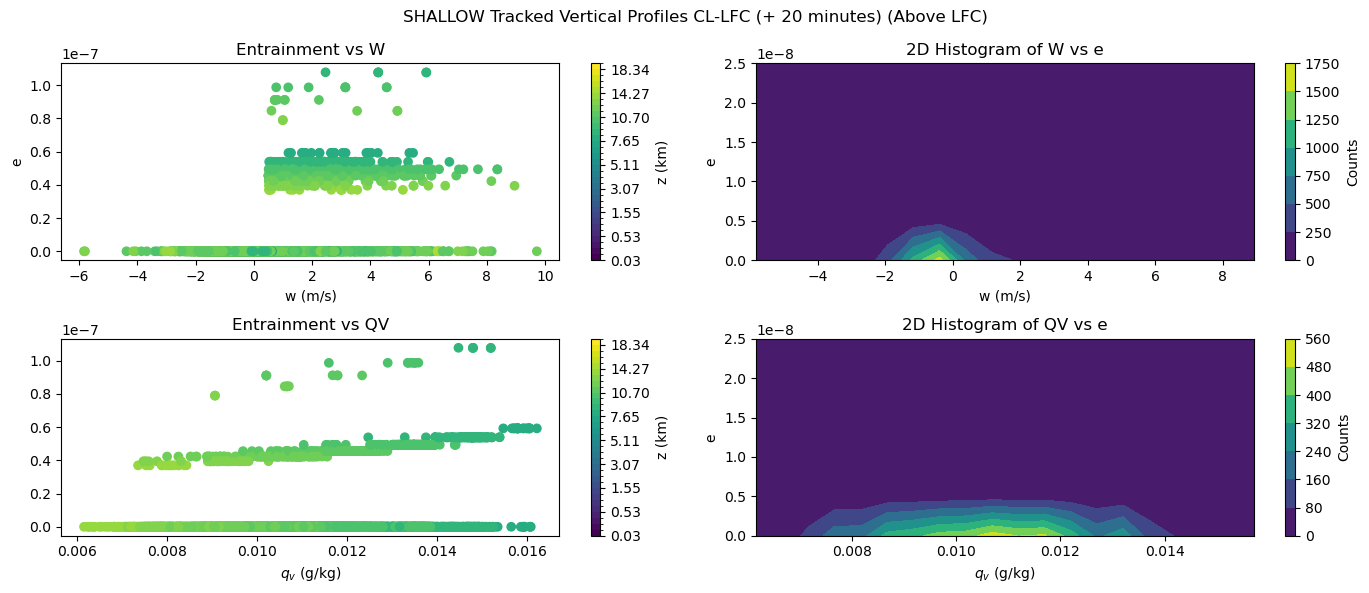

In [361]:
[ws,qvs,es,zs_lst]=data_collect(SHALLOW_out_nz,type='above')

# Create a figure and GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
ax1 = plt.subplot(gs[0,0])  
ax2 = plt.subplot(gs[0,1]) 

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

# Labels
cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
ax1.set_xlabel('w (m/s)')
ax1.set_ylabel('e')
ax1.set_title('Entrainment vs W')
# ax1.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax2.set_aspect('auto')

# Set labels and title for ax2
ax2.set_ylim((0,0.25e-7))
ax2.set_xlabel('w (m/s)')
ax2.set_ylabel('e')
ax2.set_title('2D Histogram of W vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# ##############################

# Create subplots using GridSpec
ax3 = plt.subplot(gs[1,0])  # Left subplot
ax4 = plt.subplot(gs[1,1])  # Right subplot

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
ax3.set_xlabel(r'$q_v$ (g/kg)')
ax1.set_ylabel('e')
ax3.set_title('Entrainment vs QV')
# ax3.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax4.set_aspect('auto')

# Set labels and title for ax2
ax4.set_ylim((0,0.25e-7))
ax4.set_xlabel(r'$q_v$ (g/kg)')
ax4.set_ylabel('e')
ax4.set_title('2D Histogram of QV vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

plt.suptitle('SHALLOW Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Above LFC)')
plt.tight_layout()



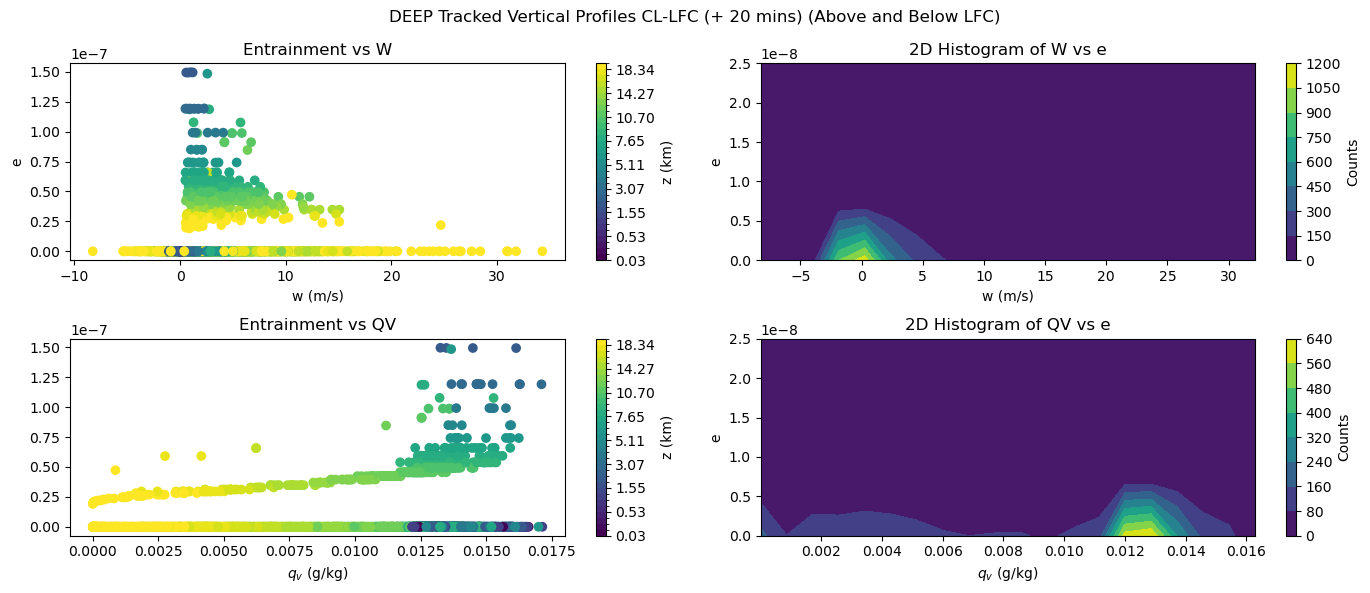

In [362]:
# DEEP
[ws,qvs,es,zs_lst]=data_collect(DEEP_out_nz,type='above_below')


# Create a figure and GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
ax1 = plt.subplot(gs[0,0])  
ax2 = plt.subplot(gs[0,1]) 

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

# Labels
cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
ax1.set_xlabel('w (m/s)')
ax1.set_ylabel('e')
ax1.set_title('Entrainment vs W')
# ax1.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax2.set_aspect('auto')

# Set labels and title for ax2
ax2.set_ylim((0,0.25e-7))
ax2.set_xlabel('w (m/s)')
ax2.set_ylabel('e')
ax2.set_title('2D Histogram of W vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# ##############################

# Create subplots using GridSpec
ax3 = plt.subplot(gs[1,0])  # Left subplot
ax4 = plt.subplot(gs[1,1])  # Right subplot

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
ax3.set_xlabel(r'$q_v$ (g/kg)')
ax1.set_ylabel('e')
ax3.set_title('Entrainment vs QV')
# ax3.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax4.set_aspect('auto')

# Set labels and title for ax2
ax4.set_ylim((0,0.25e-7))
ax4.set_xlabel(r'$q_v$ (g/kg)')
ax4.set_ylabel('e')
ax4.set_title('2D Histogram of QV vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

plt.suptitle('DEEP Tracked Vertical Profiles CL-LFC (+ 20 mins) (Above and Below LFC)')
plt.tight_layout()



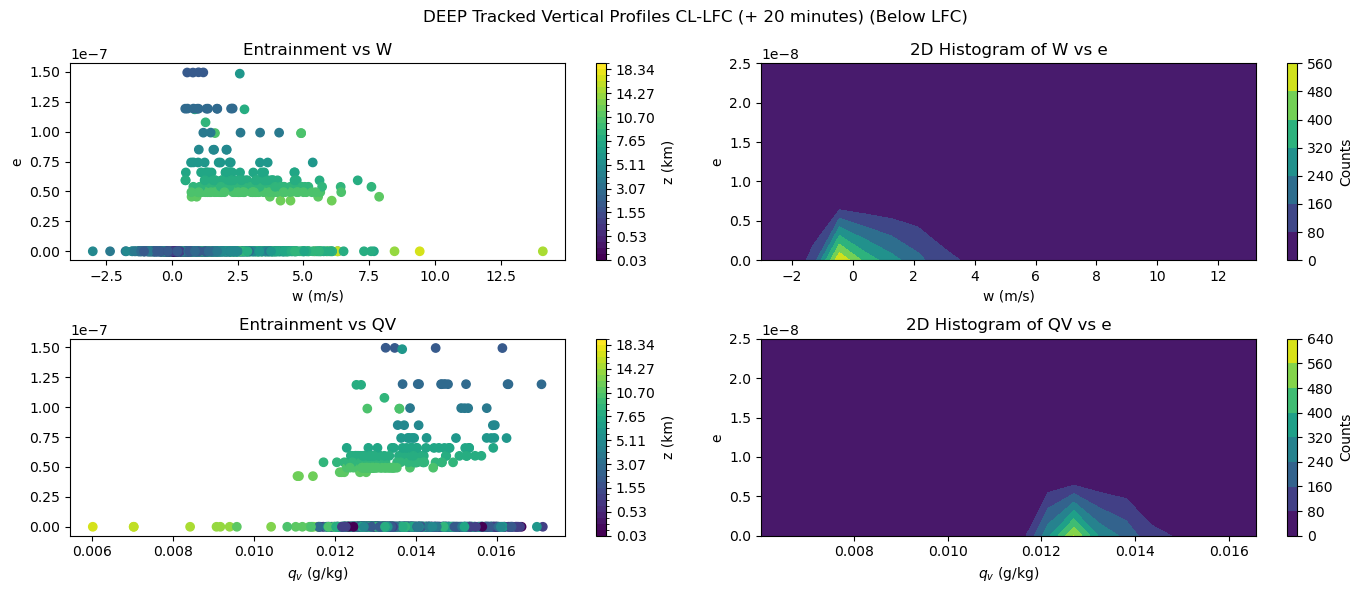

In [363]:
[ws,qvs,es,zs_lst]=data_collect(DEEP_out_nz,type='below')

# Create a figure and GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
ax1 = plt.subplot(gs[0,0])  
ax2 = plt.subplot(gs[0,1]) 

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

# Labels
cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
ax1.set_xlabel('w (m/s)')
ax1.set_ylabel('e')
ax1.set_title('Entrainment vs W')
# ax1.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax2.set_aspect('auto')

# Set labels and title for ax2
ax2.set_ylim((0,0.25e-7))
ax2.set_xlabel('w (m/s)')
ax2.set_ylabel('e')
ax2.set_title('2D Histogram of W vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# ##############################

# Create subplots using GridSpec
ax3 = plt.subplot(gs[1,0])  # Left subplot
ax4 = plt.subplot(gs[1,1])  # Right subplot

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
ax3.set_xlabel(r'$q_v$ (g/kg)')
ax1.set_ylabel('e')
ax3.set_title('Entrainment vs QV')
# ax3.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax4.set_aspect('auto')

# Set labels and title for ax2
ax4.set_ylim((0,0.25e-7))
ax4.set_xlabel(r'$q_v$ (g/kg)')
ax4.set_ylabel('e')
ax4.set_title('2D Histogram of QV vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

plt.suptitle('DEEP Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Below LFC)')
plt.tight_layout()



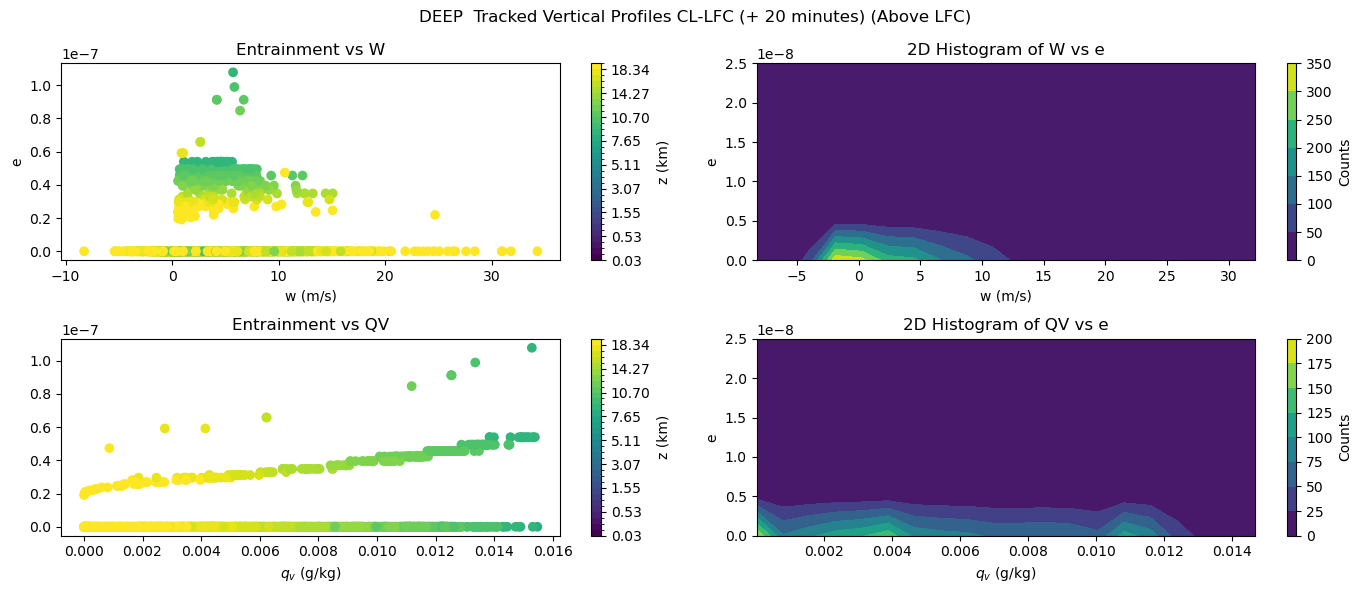

In [365]:
[ws,qvs,es,zs_lst]=data_collect(DEEP_out_nz,type='above')

# Create a figure and GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
ax1 = plt.subplot(gs[0,0])  
ax2 = plt.subplot(gs[0,1]) 

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

# Labels
cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
ax1.set_xlabel('w (m/s)')
ax1.set_ylabel('e')
ax1.set_title('Entrainment vs W')
# ax1.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax2.set_aspect('auto')

# Set labels and title for ax2
ax2.set_ylim((0,0.25e-7))
ax2.set_xlabel('w (m/s)')
ax2.set_ylabel('e')
ax2.set_title('2D Histogram of W vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# ##############################

# Create subplots using GridSpec
ax3 = plt.subplot(gs[1,0])  # Left subplot
ax4 = plt.subplot(gs[1,1])  # Right subplot

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
ax3.set_xlabel(r'$q_v$ (g/kg)')
ax1.set_ylabel('e')
ax3.set_title('Entrainment vs QV')
# ax3.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax4.set_aspect('auto')

# Set labels and title for ax2
ax4.set_ylim((0,0.25e-7))
ax4.set_xlabel(r'$q_v$ (g/kg)')
ax4.set_ylabel('e')
ax4.set_title('2D Histogram of QV vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

plt.suptitle('DEEP  Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Above LFC)')
plt.tight_layout()



In [ ]:
#GET 3D Entrainment Array ***
dir3=dir+'Project_Algorithms/Entrainment/3D_entrainment_profiles.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_e_g = h5f["profile_array_e_g"][:]
    profile_array_e_c = h5f["profile_array_e_c"][:]
    profile_array_d_g = h5f["profile_array_d_g"][:]
    profile_array_d_c = h5f["profile_array_d_c"][:]

In [381]:
#ALL SBZ
#SBZ vs nonSBZ 
#############################################################

#FINDING SBZ CONVERGENCE

#FIND ALL X MAXES
import sys
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir+'../Functions'
sys.path.append(path)
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

TF=False
if TF==False:
    print('Loading In Data')
    u_data=data['u'].interp(xf=data['xh']).data
    v_data=data['v'].interp(yf=data['yh']).data
    TF=True


from NumericalFunctions import *
def find_SBZ_xmaxs():
    
    print('calculating convergence and taking mean')
    Conv=-(Ddx(u_data,1000)+Ddy(v_data,1000))
    
    zlev=4
    Conv_ymean=np.mean(Conv[:,zlev],axis=1)
    xmaxs=np.argmax(Conv_ymean, axis=1)

    return xmaxs

# SUBSETTING OUT SBZS

def subset_SBZ(out_nz):
    xmaxs=find_SBZ_xmaxs()

    SBZ_subset=[]
    # test=[] #TESTING
    
    for ind in np.arange(out_nz.shape[0]):
        
        row=out_nz[ind]
        p=row[0]
        t=row[4]

        kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
        if X[t,p] in np.arange( (xmaxs[t]-2*kms),(xmaxs[t]+2*kms) +1):
            SBZ_subset.append(ind)
            # test.append(p) #TESTING
    
    SBZ_out_nz=out_nz[SBZ_subset]
    print(f'there are a total of {len(SBZ_out_nz)} ALL SBZ CL parcels')

    valid_range=np.arange(out_nz.shape[0])
    nonSBZ_out_nz=out_nz[list(set(valid_range) - set(SBZ_subset))]
    print(f'there are a total of {len(nonSBZ_out_nz)} ALL nonSBZ CL parcels')
    return SBZ_out_nz,nonSBZ_out_nz
##############################################################
[ALL_SBZ_out_nz,ALL_nonSBZ_out_nz]=subset_SBZ(out_nz)

Loading In Data
calculating convergence and taking mean
there are a total of 117 ALL SBZ CL parcels
there are a total of 1971 ALL nonSBZ CL parcels


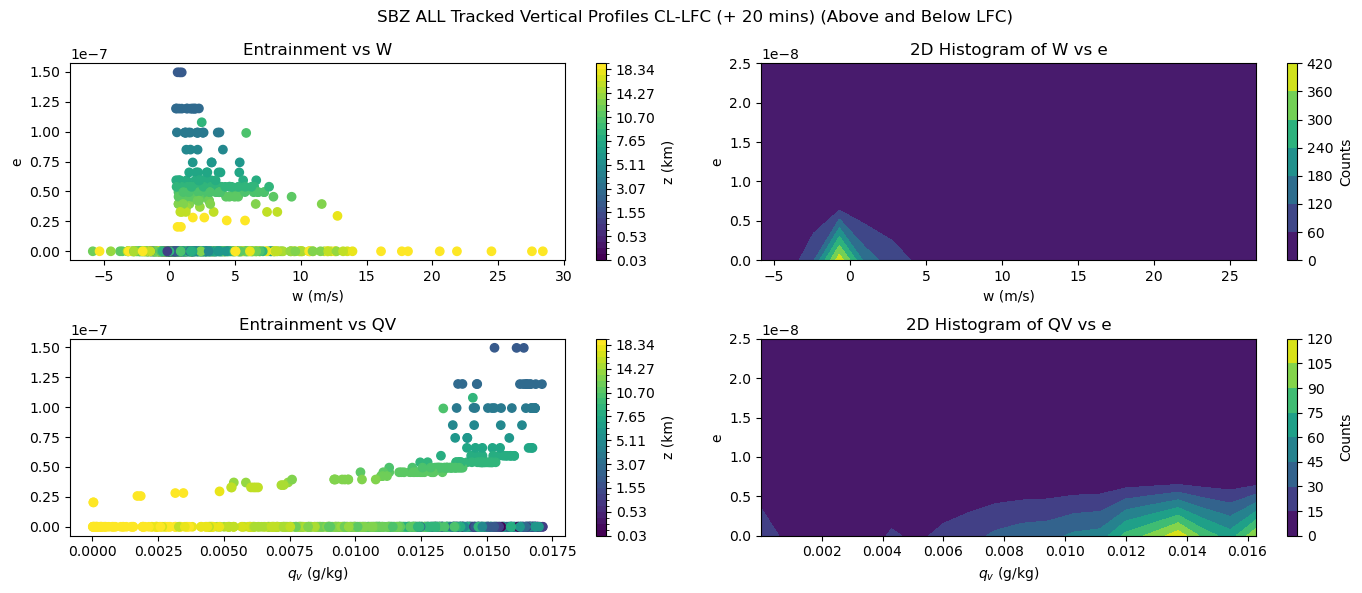

In [384]:
# SBZ ALL
#ABOVE and BELOW LFC
[ws,qvs,es,zs_lst]=data_collect(ALL_SBZ_out_nz,type='above_below')


# Create a figure and GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
ax1 = plt.subplot(gs[0,0])  
ax2 = plt.subplot(gs[0,1]) 

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

# Labels
cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
ax1.set_xlabel('w (m/s)')
ax1.set_ylabel('e')
ax1.set_title('Entrainment vs W')
# ax1.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax2.set_aspect('auto')

# Set labels and title for ax2
ax2.set_ylim((0,0.25e-7))
ax2.set_xlabel('w (m/s)')
ax2.set_ylabel('e')
ax2.set_title('2D Histogram of W vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# ##############################

# Create subplots using GridSpec
ax3 = plt.subplot(gs[1,0])  # Left subplot
ax4 = plt.subplot(gs[1,1])  # Right subplot

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
ax3.set_xlabel(r'$q_v$ (g/kg)')
ax1.set_ylabel('e')
ax3.set_title('Entrainment vs QV')
# ax3.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax4.set_aspect('auto')

# Set labels and title for ax2
ax4.set_ylim((0,0.25e-7))
ax4.set_xlabel(r'$q_v$ (g/kg)')
ax4.set_ylabel('e')
ax4.set_title('2D Histogram of QV vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

plt.suptitle('SBZ ALL Tracked Vertical Profiles CL-LFC (+ 20 mins) (Above and Below LFC)')
plt.tight_layout()



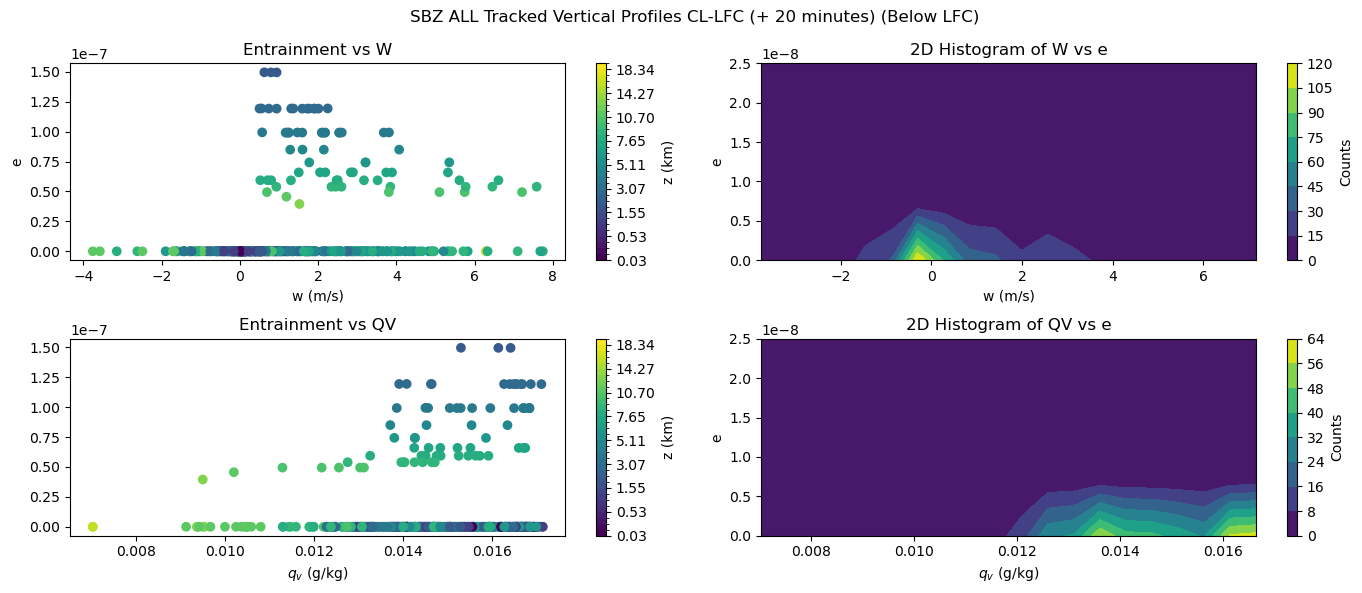

In [385]:
[ws,qvs,es,zs_lst]=data_collect(ALL_SBZ_out_nz,type='below')

# Create a figure and GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
ax1 = plt.subplot(gs[0,0])  
ax2 = plt.subplot(gs[0,1]) 

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

# Labels
cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
ax1.set_xlabel('w (m/s)')
ax1.set_ylabel('e')
ax1.set_title('Entrainment vs W')
# ax1.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax2.set_aspect('auto')

# Set labels and title for ax2
ax2.set_ylim((0,0.25e-7))
ax2.set_xlabel('w (m/s)')
ax2.set_ylabel('e')
ax2.set_title('2D Histogram of W vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# ##############################

# Create subplots using GridSpec
ax3 = plt.subplot(gs[1,0])  # Left subplot
ax4 = plt.subplot(gs[1,1])  # Right subplot

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
ax3.set_xlabel(r'$q_v$ (g/kg)')
ax1.set_ylabel('e')
ax3.set_title('Entrainment vs QV')
# ax3.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax4.set_aspect('auto')

# Set labels and title for ax2
ax4.set_ylim((0,0.25e-7))
ax4.set_xlabel(r'$q_v$ (g/kg)')
ax4.set_ylabel('e')
ax4.set_title('2D Histogram of QV vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

plt.suptitle('SBZ ALL Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Below LFC)')
plt.tight_layout()



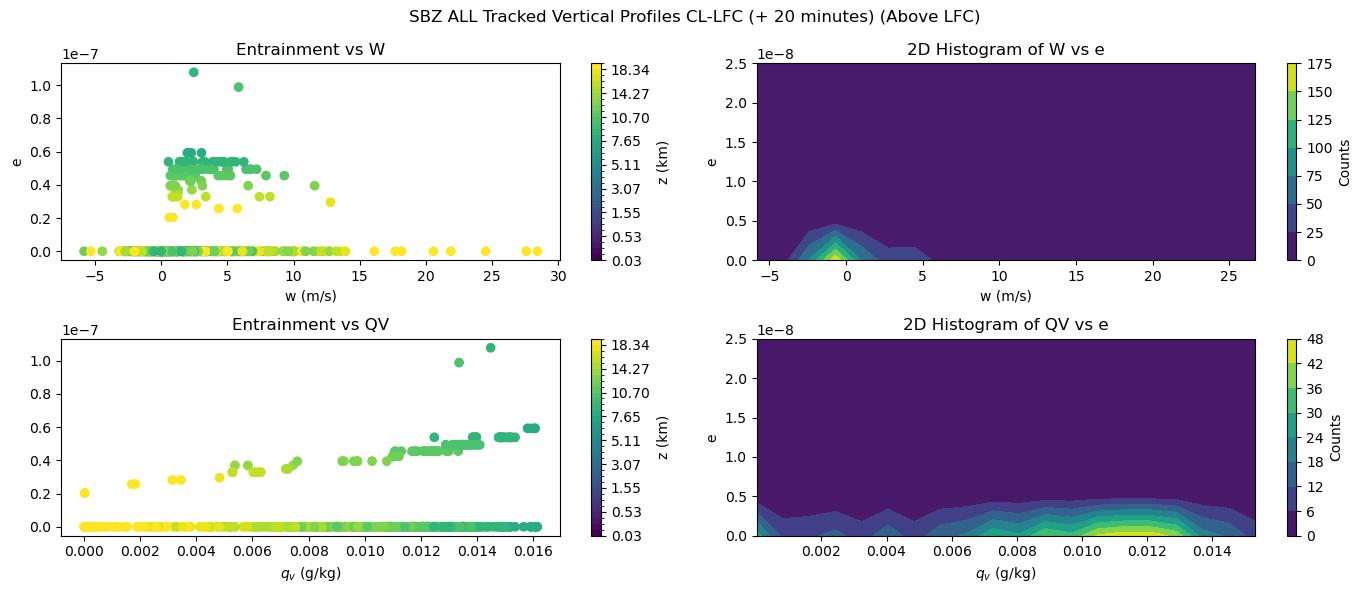

In [386]:
[ws,qvs,es,zs_lst]=data_collect(ALL_SBZ_out_nz,type='above')

# Create a figure and GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
ax1 = plt.subplot(gs[0,0])  
ax2 = plt.subplot(gs[0,1]) 

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

# Labels
cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
ax1.set_xlabel('w (m/s)')
ax1.set_ylabel('e')
ax1.set_title('Entrainment vs W')
# ax1.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax2.set_aspect('auto')

# Set labels and title for ax2
ax2.set_ylim((0,0.25e-7))
ax2.set_xlabel('w (m/s)')
ax2.set_ylabel('e')
ax2.set_title('2D Histogram of W vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# ##############################

# Create subplots using GridSpec
ax3 = plt.subplot(gs[1,0])  # Left subplot
ax4 = plt.subplot(gs[1,1])  # Right subplot

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm)#color='blue')

cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
ax3.set_xlabel(r'$q_v$ (g/kg)')
ax1.set_ylabel('e')
ax3.set_title('Entrainment vs QV')
# ax3.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax4.set_aspect('auto')

# Set labels and title for ax2
ax4.set_ylim((0,0.25e-7))
ax4.set_xlabel(r'$q_v$ (g/kg)')
ax4.set_ylabel('e')
ax4.set_title('2D Histogram of QV vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

plt.suptitle('SBZ ALL Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Above LFC)')
plt.tight_layout()



In [ ]:
#TRACKED TRAJECTORY ENTRAINMENT/DETRAINMENT
################################################################

In [6]:
# if 'lfc_data' not in globals():
#     lfc_data = data['lfc'].data
# def mean_LFC(out_nz):
    
        
#     import numpy as np
#     import itertools
    
#     # Assuming out_nz, Y, X, and lfc_data are defined
#     all_lfc_values = []  # List to store all results
    
#     # Loop over each row in out_nz
#     for ind, row in enumerate(out_nz):
#         ts = np.arange(row[4], row[5] + 1)  # Create the range for time indices
#         ys = Y[ts, row[0]]  # y indices
#         xs = X[ts, row[0]]  # x indices
        
#         # Generate tuples for element-wise indexing
#         index_tuples = list(itertools.zip_longest(ts, ys, xs, fillvalue=None))
        
#         # Collect lfc_data values for the current row
#         lfc_values = [lfc_data[t, y, x] for t, y, x in index_tuples]
        
#         # Append to the list
#         all_lfc_values.append(lfc_values)
    
#     all_lfc_values=[value for row_values in all_lfc_values for value in row_values]
    
#     mean_cloudbase=np.mean(all_lfc_values)/1000
#     return mean_cloudbase
# # mean_LFC(ALL_out_nz)
# # mean_LFC(SHALLOW_out_nz)
# # mean_LFC(DEEP_out_nz)

# # mean_LFC(save_nz)
# # mean_LFC(SHALLOW_save_nz)
# # mean_LFC(DEEP_save_nz)

# # mean_LFC(ALL_SBZ_out_nz)
# # mean_LFC(SHALLOW_SBZ_out_nz)
# # mean_LFC(DEEP_SBZ_out_nz)

# # mean_LFC(ALL_nonSBZ_out_nz)
# # mean_LFC(SHALLOW_nonSBZ_out_nz)
# # mean_LFC(DEEP_nonSBZ_out_nz)

In [19]:
# # Reading Back Data Later
# ##############
# import h5py
# dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/job_array/'
# with h5py.File(dir2+'lagrangian_binary_array.h5', 'r') as f:
#     # Load the dataset by its name
#     A_g = f['A_g'][:]
#     A_c = f['A_c'][:]
#     Z = f['Z'][:]
#     Y = f['Y'][:]
#     X = f['X'][:]

# # #Making Time Matrix
# # rows, cols = A.shape[0], A.shape[1]
# # T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [90]:
#READING BACK IN ***
dir3=dir+'Project_Algorithms/Entrainment/3D_entrainment_profiles_ENTRAINGOOD.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_e_g = h5f["profile_array_e_g"][:]
    profile_array_e_c = h5f["profile_array_e_c"][:]
    profile_array_d_g = h5f["profile_array_d_g"][:]
    profile_array_d_c = h5f["profile_array_d_c"][:]

In [91]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


out=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 
###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder=out_nz.copy(); run=True
############################################################
print(f'there are a total of {len(out_nz)} CL parcels and {len(save_nz)} nonCL parcels')


ALL_out_nz=out_nz.copy(); ALL_save_nz=save_nz.copy()

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
there are a total of 2088 CL parcels and 1717 nonCL parcels


In [92]:
#SHALLOW

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def SHALLOW_threshold(zthresh,type):

    if type=='CL':
        out_nz=ALL_out_nz.copy()
    if type=='nonCL':
        out_nz=ALL_save_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################

convectivelevel=4 #4km
SHALLOW_out_nz=SHALLOW_threshold(convectivelevel,type='CL')
SHALLOW_save_nz=SHALLOW_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(SHALLOW_out_nz)} CL parcels and {len(SHALLOW_save_nz)} nonCL parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
there are a total of 1152 CL parcels and 1048 nonCL parcels


In [93]:
#DEEP

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def DEEP_threshold(zthresh,type):
    if type=='CL':
        out_nz=ALL_out_nz.copy()
    if type=='nonCL':
        out_nz=ALL_save_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################

convectivelevel=6 #4km
DEEP_out_nz=DEEP_threshold(convectivelevel,type='CL')
DEEP_save_nz=DEEP_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(DEEP_out_nz)} CL parcels and {len(DEEP_save_nz)} nonCL parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
there are a total of 374 CL parcels and 314 nonCL parcels


In [94]:
#FINDING MEAN CLOUD BASE
zh=data['zh'].values
w_thresh2=0.5
qcqi_thresh=1e-6
type='all'

if 'emptylike' not in globals():
    print('loading neccessary variables')
    # variable='w'; w_data=data[variable] #get w data
    # w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    emptylike=True
    print('done')

if type=='all':
    out_nz=ALL_out_nz.copy()
if type=='deep':
    out_nz=DEEP_out_nz.copy()
if type=='shallow':
    out_nz=SHALLOW_out_nz.copy()

zhs=data['zh'].values
profile_array =np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
profile_array[:,1]=zhs;

# cloudbase_lst=[]
after=4 #20 minutes
for row in range(out_nz.shape[0]):
    p=out_nz[row,0]
    
    # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
    ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(out_nz[row, 4], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]
    for t, z, y, x in zip(ts, zs, ys, xs):
        # var1=w_data[t,z,y,x]
        var2=qc_plus_qi[t,z,y,x]

        if (var2>=qcqi_thresh):
        # if (var1>=w_thresh2) & (var2>=qcqi_thresh):
            profile_array[z,0]+=1
            # cloudbase_lst.append(zh[z])
            break

# print(np.mean(cloudbase_lst))
# print(np.min(cloudbase_lst))
# plt.hist(cloudbase_lst,bins=40,orientation='horizontal');
all_cloudbase=zh[np.where(profile_array[:,0]!=0)[0][0]]
print(all_cloudbase)

1.5475868


In [100]:
#MAKING ENTRAINMENT PROFILE ARRAY
type2='general'
# type2='cloudy'

if type2=='general':
    A=A_g #COMMENT OUT IF USING PRECALCULATED DATA
    profile_array_e=profile_array_e_g
    profile_array_d=profile_array_d_g
if type2=='cloudy':
    A=A_c #COMMENT OUT IF USING PRECALCULATED DATA
    profile_array_e=profile_array_e_c
    profile_array_d=profile_array_d_c


after=4 #20 minutes

zhs=data['zh'].values
ALL_profile_array_e=np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
ALL_profile_array_d=ALL_profile_array_e.copy()
ALL_profile_array_e[:,1]=zhs;ALL_profile_array_d[:,1]=zhs

for row in range(out_nz.shape[0]):
    p=out_nz[row,0]
    
    # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
    ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(out_nz[row, 4], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]
    for t, z, y, x in zip(ts, zs, ys, xs):
        # e=ed3d(A,t,z,y,x,type='e')
        d=ed3d(A,t,z,y,x,type='d')
        e=profile_array_e[t,z,y,x]
        # d=profile_array_d[t,z,y,x]
        ALL_profile_array_e[z,0]+=e
        ALL_profile_array_d[z,0]+=d

print('done')

done


In [99]:
#MAKING PROFILE ARRAY
type2='general'
# type2='cloudy'

if type2=='general':
    A=A_g #COMMENT OUT IF USING PRECALCULATED DATA
    profile_array_e=profile_array_e_g
    profile_array_d=profile_array_d_g
if type2=='cloudy':
    A=A_c #COMMENT OUT IF USING PRECALCULATED DATA
    profile_array_e=profile_array_e_c
    profile_array_d=profile_array_d_c
    
zhs=data['zh'].values
SHALLOW_profile_array_e=np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
SHALLOW_profile_array_d=SHALLOW_profile_array_e.copy()
SHALLOW_profile_array_e[:,1]=zhs;SHALLOW_profile_array_d[:,1]=zhs

after=4 #20 minutes
# after=0

for row in range(SHALLOW_out_nz.shape[0]):
    p=SHALLOW_out_nz[row,0]
    
    # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
    ts_end = min(SHALLOW_out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(SHALLOW_out_nz[row, 4], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]
    for t, z, y, x in zip(ts, zs, ys, xs):
        # e=ed3d(A,t,z,y,x,type='e')
        d=ed3d(A,t,z,y,x,type='d')
        e=profile_array_e[t,z,y,x]
        # d=profile_array_d[t,z,y,x]
        SHALLOW_profile_array_e[z,0]+=e
        SHALLOW_profile_array_d[z,0]+=d

print('done')

done


In [102]:
#MAKING PROFILE ARRAY

type2='general'
# type2='cloudy'

if type2=='general':
    A=A_g #COMMENT OUT IF USING PRECALCULATED DATA
    profile_array_e=profile_array_e_g
    profile_array_d=profile_array_d_g
if type2=='cloudy':
    A=A_c #COMMENT OUT IF USING PRECALCULATED DATA
    profile_array_e=profile_array_e_c
    profile_array_d=profile_array_d_c
    
zhs=data['zh'].values
DEEP_profile_array_e=np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
DEEP_profile_array_d=DEEP_profile_array_e.copy()
DEEP_profile_array_e[:,1]=zhs;DEEP_profile_array_d[:,1]=zhs

after=4 #20 minutes
# after=0

for row in range(DEEP_out_nz.shape[0]):
    p=DEEP_out_nz[row,0]
    
    # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
    ts_end = min(DEEP_out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(DEEP_out_nz[row, 4], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]
    for t, z, y, x in zip(ts, zs, ys, xs):
        # e=ed3d(A,t,z,y,x,type='e')
        d=ed3d(A,t,z,y,x,type='d')
        e=profile_array_e[t,z,y,x]
        # d=profile_array_d[t,z,y,x]
        DEEP_profile_array_e[z,0]+=e
        DEEP_profile_array_d[z,0]+=d

print('done')

done


Text(0.5, 0.98, 'Entrainment and Detrainment')

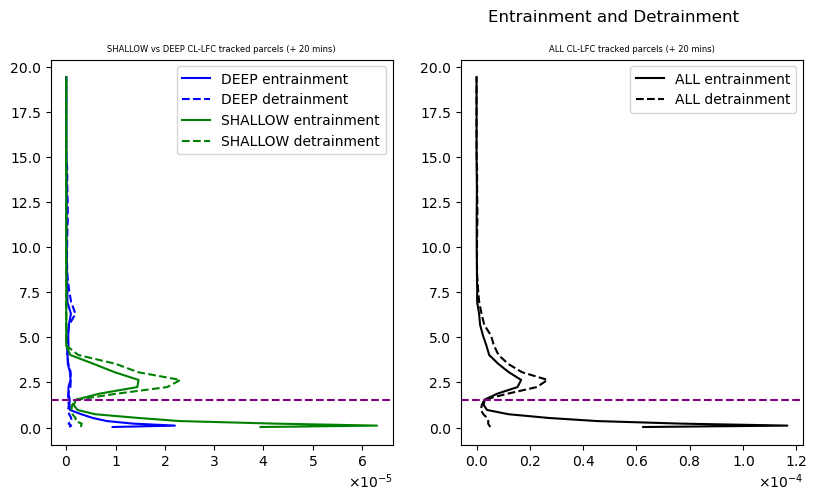

In [105]:
fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 3, figure=fig)

# First subplot (left side) for DEEP vs SHALLOW
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(DEEP_profile_array_e[:, 0], DEEP_profile_array_e[:, 1], label='DEEP entrainment', color='blue')
ax1.plot(DEEP_profile_array_d[:, 0]*-1, DEEP_profile_array_d[:, 1], label='DEEP detrainment', color='blue',linestyle='dashed')
ax1.plot(SHALLOW_profile_array_e[:, 0], SHALLOW_profile_array_e[:, 1], label='SHALLOW entrainment', color='green')
ax1.plot(SHALLOW_profile_array_d[:, 0]*-1, SHALLOW_profile_array_d[:, 1], label='SHALLOW detrainment', color='green', linestyle='dashed')
ax1.set_title('SHALLOW vs DEEP CL-LFC tracked parcels (+ 20 mins)',fontsize=6)
ax1.legend()

# Second subplot (right side) for ALL
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(ALL_profile_array_e[:, 0], ALL_profile_array_e[:, 1], color='k', label='ALL entrainment')
ax2.plot(ALL_profile_array_d[:, 0]*-1, ALL_profile_array_d[:, 1], color='k', label='ALL detrainment',linestyle='dashed')
ax2.set_title('ALL CL-LFC tracked parcels (+ 20 mins)',fontsize=6)
ax2.legend()


#ADD ALL,SHALLOW,DEEP nonCL parcels
# ax3 = fig.add_subplot(gs[0, 1])
# ax3.plot(nonCL_profile_array_e[:, 0], nonCL_profile_array_e[:, 1], label='entrainment')
# ax3.plot(nonCL_profile_array_d[:, 0], nonCL_profile_array_d[:, 1], label='detrainment')
# ax3.set_title('ALL nonCL CL-LFC tracked parcels')
# ax3.legend()

# #Mean LFC
# ax1.axhline(np.mean((mean_LFC(SHALLOW_out_nz),
#                       mean_LFC(DEEP_out_nz))),color='blue',linestyle='dashed')

# ax2.axhline(mean_LFC(ALL_out_nz),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
for axis in [ax1,ax2]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2])

fig.suptitle('Entrainment and Detrainment') #**********

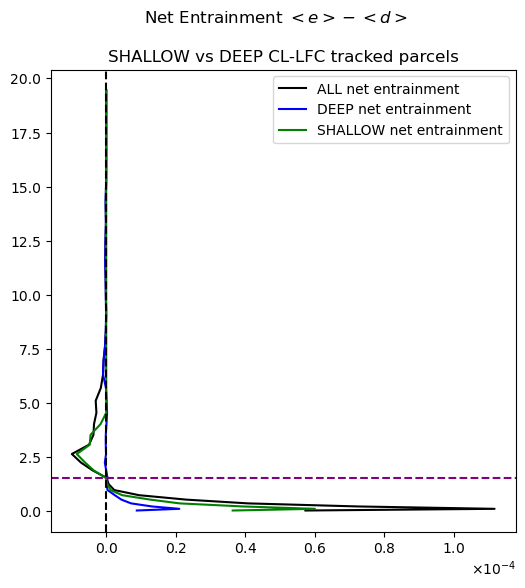

In [109]:
#NET ENTRAINMENT

fig = plt.figure(figsize=(6, 6))
fig.suptitle(r'Net Entrainment $<e>-<d>$')
gs = gridspec.GridSpec(1, 1, figure=fig)


# First subplot (left side) for DEEP vs SHALLOW
ax1 = fig.add_subplot(gs[0, 0])

plotting_data=ALL_profile_array_e[:, 0]-ALL_profile_array_d[:, 0]*-1
ax1.plot(plotting_data, ALL_profile_array_e[:, 1], color='black',label='ALL net entrainment')
plotting_data=DEEP_profile_array_e[:, 0]-DEEP_profile_array_d[:, 0]*-1
ax1.plot(plotting_data, DEEP_profile_array_e[:, 1], label='DEEP net entrainment', color='blue')
plotting_data=SHALLOW_profile_array_e[:, 0]-SHALLOW_profile_array_d[:, 0]*-1
ax1.plot(plotting_data, SHALLOW_profile_array_e[:, 1], label='SHALLOW net entrainment', color='green')

plt.axvline(0,color='black',linestyle='dashed')
ax1.set_title('SHALLOW vs DEEP CL-LFC tracked parcels')
ax1.legend()


ax2.set_title('ALL CL-LFC tracked parcels')
ax2.legend()


#ADD ALL,SHALLOW,DEEP nonCL parcels
# ax3 = fig.add_subplot(gs[0, 1])
# ax3.plot(nonCL_profile_array_e[:, 0], nonCL_profile_array_e[:, 1], label='entrainment')
# ax3.plot(nonCL_profile_array_d[:, 0], nonCL_profile_array_d[:, 1], label='detrainment')
# ax3.set_title('ALL nonCL CL-LFC tracked parcels')
# ax3.legend()




# #Mean LFC
# ax1.axhline(np.mean((mean_LFC(ALL_out_nz),mean_LFC(SHALLOW_out_nz),
#                       mean_LFC(DEEP_out_nz))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
for axis in [ax1,ax2]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2])

In [ ]:
######

In [115]:
#CL vs nonCL 
#MAKING PROFILE ARRAY

type2='general'
# type2='cloudy'

if type2=='general':
    A=A_g #COMMENT OUT IF USING PRECALCULATED DATA
    profile_array_e=profile_array_e_g
    profile_array_d=profile_array_d_g
if type2=='cloudy':
    A=A_c #COMMENT OUT IF USING PRECALCULATED DATA
    profile_array_e=profile_array_e_c
    profile_array_d=profile_array_d_c

def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

def CL_tracked_ed_profile(type,edtype):
    after=4 #20 minutes
    # after=0

    if type=='all':
        out_nz=ALL_out_nz.copy()
    if type=='shallow':
        out_nz=SHALLOW_out_nz.copy()
    if type=='deep':
        out_nz=DEEP_out_nz.copy()
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_nz.shape[0]):
        p=out_nz[row,0]
        
        # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
        ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_nz[row, 4], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):      
            if edtype=='e':
                # var=ed3d(A,t,z,y,x,type='e')
                var=profile_array_e[t,z,y,x]
            elif edtype=='d':
                var=ed3d(A,t,z,y,x,type='d')
                # var=profile_array_d[t,z,y,x]
                
            profile_array[z,0]+=var;profile_array[z,1]+=1
    return profile_array

print('all')
ALL_e=CL_tracked_ed_profile('all','e')
ALL_d=CL_tracked_ed_profile('all','d')
print('shallow')
SHALLOW_e=CL_tracked_ed_profile('shallow','e')
SHALLOW_d=CL_tracked_ed_profile('shallow','d')
print('deep')
DEEP_e=CL_tracked_ed_profile('deep','e')
DEEP_d=CL_tracked_ed_profile('deep','d')

all
shallow
deep


In [116]:
#CL vs nonCL #**********
#MAKING PROFILE ARRAY
type2='general'
# type2='cloudy'

if type2=='general':
    A=A_g #COMMENT OUT IF USING PRECALCULATED DATA
    profile_array_e=profile_array_e_g
    profile_array_d=profile_array_d_g
if type2=='cloudy':
    A=A_c #COMMENT OUT IF USING PRECALCULATED DATA
    profile_array_e=profile_array_e_c
    profile_array_d=profile_array_d_c

def nonCL_tracked_ed_profile(type,edtype):
    after=4 #20 minutes
    # after=0

    if type=='all':
        out_nz=ALL_save_nz.copy()
    if type=='shallow':
        out_nz=SHALLOW_save_nz.copy()
    if type=='deep':
        out_nz=DEEP_save_nz.copy()

    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_nz.shape[0]):
        p=out_nz[row,0]
        
        # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
        ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_nz[row, 4], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):
            if edtype=='e':
                # var=ed3d(A,t,z,y,x,type='e')
                var=profile_array_e[t,z,y,x]
            elif edtype=='d':
                var=ed3d(A,t,z,y,x,type='d')
                # var=profile_array_d[t,z,y,x]
                
            profile_array[z,0]+=var;profile_array[z,1]+=1
    return profile_array

print('all')
nonCL_ALL_e=nonCL_tracked_ed_profile('all','e')
nonCL_ALL_d=nonCL_tracked_ed_profile('all','d')
print('shallow')
nonCL_SHALLOW_e=nonCL_tracked_ed_profile('shallow','e')
nonCL_SHALLOW_d=nonCL_tracked_ed_profile('shallow','d')
print('deep')
nonCL_DEEP_e=nonCL_tracked_ed_profile('deep','e')
nonCL_DEEP_d=nonCL_tracked_ed_profile('deep','d')

all
shallow
deep


In [ ]:
xlims=[] #FIXING XAXIS
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

#MAKING DETRAINMENT VALUES POSITIVE
ALL_d[:,0]*=-1;SHALLOW_d[:,0]*=-1;DEEP_d[:,0]*=-1
nonCL_ALL_d[:,0]*=-1;nonCL_SHALLOW_d[:,0]*=-1;nonCL_DEEP_d[:,0]*=-1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (ALL_e, SHALLOW_e, DEEP_e, 'e', 'CL'),
    (ALL_d, SHALLOW_d, DEEP_d, 'd', 'CL'),
    (nonCL_ALL_e, nonCL_SHALLOW_e, DEEP_e, 'e', 'nonCL'),
    (nonCL_ALL_d, nonCL_SHALLOW_d, DEEP_d, 'd', 'nonCL'),
]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])
    
    # # Compute the averaged profile
    # ALL_profile = averaged_profiles(ALL_profile_array)
    # SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    # DEEP_profile = averaged_profiles(DEEP_profile_array)
    ALL_profile=ALL_profile_array.copy()
    SHALLOW_profile=SHALLOW_profile_array.copy()
    DEEP_profile=DEEP_profile_array.copy()
    
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, -1],color='black',label='ALL')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1],color='green',label='SHALLOW')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1],color='blue',label='DEEP')
    ax.set_xlabel(xlabel)
    ax.set_title(CLlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)
    

#LEGEND
    ax.legend()
# legend_ax = fig.add_subplot(gs[0, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

fix_x_limits([ax1,ax2,ax3,ax4])
fix_y_limits([ax1,ax2,ax3,ax4])

#ACCESSORIES
plt.suptitle('Entrainment & Detrainment (ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL & nonCL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()


# #Mean LFC
# axs = fig.get_axes()
# ax1, ax2, ax3, ax4 = axs
# for axis in [ax1,ax2]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_nz),mean_LFC(SHALLOW_out_nz),
#                           mean_LFC(DEEP_out_nz))),color='blue',linestyle='dashed',linewidth=1.2)
# for axis in [ax3,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_save_nz),mean_LFC(SHALLOW_save_nz),
#                           mean_LFC(DEEP_save_nz))),color='blue',linestyle='dashed',linewidth=1.2)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4= axs
for axis in [ax1,ax2,ax3,ax4]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4])

(-1.8155551143862914e-05, 0.00012748958988643622)
(-0.9395961281843483, 20.41351872170344)


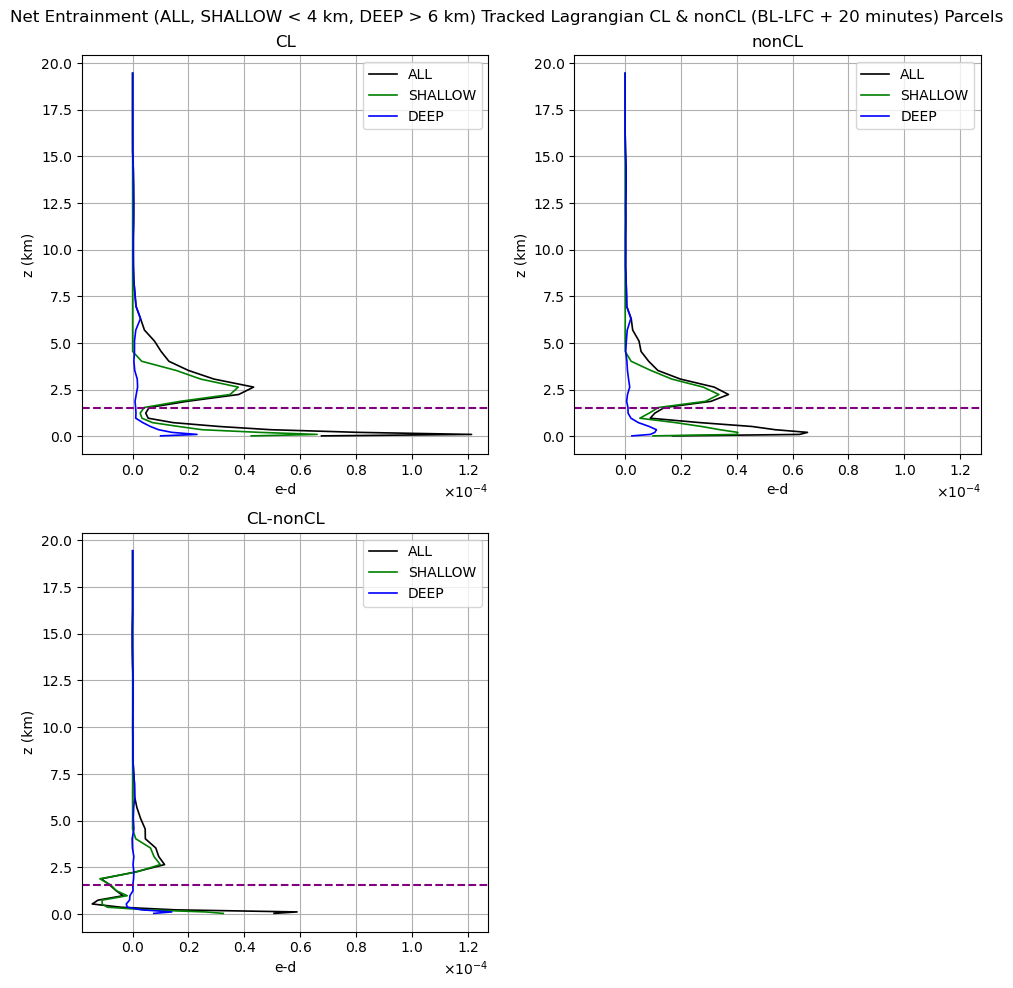

In [121]:
#NET ENTRAINMENT

xlims=[] #FIXING XAXIS
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# List of profile arrays and their corresponding labels and x-axis titles

ALL_net=ALL_e.copy(); ALL_net[:,0]-=ALL_d[:,0]
SHALLOW_net=SHALLOW_e.copy(); SHALLOW_net[:,0]-=SHALLOW_d[:,0]
DEEP_net=DEEP_e.copy(); DEEP_net[:,0]-=DEEP_d[:,0]

nonCL_ALL_net=nonCL_ALL_e.copy(); nonCL_ALL_net[:,0]-=nonCL_ALL_d[:,0]
nonCL_SHALLOW_net=nonCL_SHALLOW_e.copy(); nonCL_SHALLOW_net[:,0]-=nonCL_SHALLOW_d[:,0]
nonCL_DEEP_net=nonCL_DEEP_e.copy(); nonCL_DEEP_net[:,0]-=nonCL_DEEP_d[:,0]

ALL_CLnonCL=ALL_net.copy(); ALL_CLnonCL[:,0]-=nonCL_ALL_net[:,0]
SHALLOW_CLnonCL=SHALLOW_net.copy(); SHALLOW_CLnonCL[:,0]-=nonCL_SHALLOW_net[:,0]
DEEP_CLnonCL=DEEP_net.copy(); DEEP_CLnonCL[:,0]-=nonCL_DEEP_net[:,0]


profiles = [
    (ALL_net, SHALLOW_net, DEEP_net, 'e-d', 'CL'),
    (nonCL_ALL_net, nonCL_SHALLOW_net, nonCL_DEEP_net, 'e-d', 'nonCL'),
    (ALL_CLnonCL, SHALLOW_CLnonCL, DEEP_CLnonCL, 'e-d', 'CL-nonCL')
]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Loop through the profiles and plot them on subplots
axes = {}
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
    globals()[f'ax{i+1}'] = fig.add_subplot(gs[i])  # Dynamically create ax1, ax2, ax3, ...
    ax = globals()[f'ax{i+1}']

    
    # # Compute the averaged profile
    # ALL_profile = averaged_profiles(ALL_profile_array)
    # SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    # DEEP_profile = averaged_profiles(DEEP_profile_array)
    ALL_profile=ALL_profile_array.copy()
    SHALLOW_profile=SHALLOW_profile_array.copy()
    DEEP_profile=DEEP_profile_array.copy()
    
    
    # Plot the profile

    #linewidth
    if i == 2: 
        lw=1.2
    else: lw=1.2
        
    ax.plot(ALL_profile[:, 0], ALL_profile[:, -1],color='black',label='ALL',lw=lw)
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1],color='green',label='SHALLOW',lw=lw)
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1],color='blue',label='DEEP',lw=lw)
    ax.set_xlabel(xlabel)
    ax.set_title(CLlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    # ax.set_ylim(0,10)
    
#LEGEND
    ax.legend()
# legend_ax = fig.add_subplot(gs[0, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

fix_x_limits([ax1,ax2,ax3])
fix_y_limits([ax1,ax2,ax3])

#ACCESSORIES
plt.suptitle('Net Entrainment (ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL & nonCL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #Mean LFC
# axs = fig.get_axes()
# ax1, ax2, ax3 = axs
# for axis in [ax1]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_nz),mean_LFC(SHALLOW_out_nz),
#                           mean_LFC(DEEP_out_nz))),color='blue',linestyle='dashed',linewidth=1.2)
# for axis in [ax2]:
#     axis.axhline(np.mean((mean_LFC(ALL_save_nz),mean_LFC(SHALLOW_save_nz),
#                           mean_LFC(DEEP_save_nz))),color='blue',linestyle='dashed',linewidth=1.2)
# for axis in [ax3]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_nz),mean_LFC(SHALLOW_out_nz),
#                           mean_LFC(DEEP_out_nz),mean_LFC(ALL_save_nz),mean_LFC(SHALLOW_save_nz),
#                           mean_LFC(DEEP_save_nz))),color='blue',linestyle='dashed',linewidth=1.2)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3= axs
for axis in [ax1,ax2,ax3]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3])

In [122]:
#SBZ vs nonSBZ 
#############################################################

#FINDING SBZ CONVERGENCE

#FIND ALL X MAXES
import sys
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir+'../Functions'
sys.path.append(path)
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

TF=False
if TF==False:
    print('Loading In Data')
    u_data=data['u'].interp(xf=data['xh']).data
    v_data=data['v'].interp(yf=data['yh']).data
    TF=True


from NumericalFunctions import *
def find_SBZ_xmaxs():
    
    print('calculating convergence and taking mean')
    Conv=-(Ddx(u_data,1000)+Ddy(v_data,1000))
    
    zlev=4
    Conv_ymean=np.mean(Conv[:,zlev],axis=1)
    xmaxs=np.argmax(Conv_ymean, axis=1)

    return xmaxs

# SUBSETTING OUT SBZS

def subset_SBZ(out_nz):
    xmaxs=find_SBZ_xmaxs()

    SBZ_subset=[]
    # test=[] #TESTING
    
    for ind in np.arange(out_nz.shape[0]):
        
        row=out_nz[ind]
        p=row[0]
        t=row[4]

        kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
        if X[t,p] in np.arange( (xmaxs[t]-2*kms),(xmaxs[t]+2*kms) +1):
            SBZ_subset.append(ind)
            # test.append(p) #TESTING
    
    SBZ_out_nz=out_nz[SBZ_subset]
    print(f'there are a total of {len(SBZ_out_nz)} ALL SBZ CL parcels')

    valid_range=np.arange(out_nz.shape[0])
    nonSBZ_out_nz=out_nz[list(set(valid_range) - set(SBZ_subset))]
    print(f'there are a total of {len(nonSBZ_out_nz)} ALL nonSBZ CL parcels')
    return SBZ_out_nz,nonSBZ_out_nz

#SUBSETTING OUT SHALLOW AND DEEP FROM SBZ AND NONSBZ
def SHALLOW_threshold(zthresh,type):
    if type=='SBZ':
        out_nz=ALL_SBZ_out_nz.copy()
    if type=='nonSBZ':
        out_nz=ALL_nonSBZ_out_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)

def DEEP_threshold(zthresh,type):
    if type=='SBZ':
        out_nz=ALL_SBZ_out_nz.copy()
    if type=='nonSBZ':
        out_nz=ALL_nonSBZ_out_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################
[ALL_SBZ_out_nz,ALL_nonSBZ_out_nz]=subset_SBZ(out_nz)
SHALLOW_SBZ_out_nz=SHALLOW_threshold(4,'SBZ')
print(f'there are a total of {len(SHALLOW_SBZ_out_nz)} SHALLOW SBZ CL parcels')
SHALLOW_nonSBZ_out_nz=SHALLOW_threshold(4,'nonSBZ')
print(f'there are a total of {len(SHALLOW_nonSBZ_out_nz)} SHALLOW nonSBZ CL parcels')
DEEP_SBZ_out_nz=DEEP_threshold(6,'SBZ')
print(f'there are a total of {len(DEEP_SBZ_out_nz)} DEEP SBZ CL parcels')
DEEP_nonSBZ_out_nz=DEEP_threshold(6,'nonSBZ')
print(f'there are a total of {len(DEEP_nonSBZ_out_nz)} DEEP nonSBZ CL parcels')

Loading In Data
calculating convergence and taking mean
there are a total of 117 ALL SBZ CL parcels
there are a total of 1971 ALL nonSBZ CL parcels
there are a total of 60 SHALLOW SBZ CL parcels
there are a total of 1092 SHALLOW nonSBZ CL parcels
there are a total of 37 DEEP SBZ CL parcels
there are a total of 337 DEEP nonSBZ CL parcels


In [124]:
#SBZ vs nonSBZ
#MAKING PROFILE ARRAY

type2='general'
# type2='cloudy'

if type2=='general':
    A=A_g #COMMENT OUT IF USING PRECALCULATED DATA
    profile_array_e=profile_array_e_g
    profile_array_d=profile_array_d_g
if type2=='cloudy':
    A=A_c #COMMENT OUT IF USING PRECALCULATED DATA
    profile_array_e=profile_array_e_c
    profile_array_d=profile_array_d_c

def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

def SBZ_tracked_ed_profile(type,edtype):
    after=4 #20 minutes
    # after=0

    if type=='all':
        out_nz=ALL_SBZ_out_nz.copy()
    if type=='shallow':
        out_nz=SHALLOW_SBZ_out_nz.copy()
    if type=='deep':
        out_nz=DEEP_SBZ_out_nz.copy()
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_nz.shape[0]):
        p=out_nz[row,0]
        
        # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
        ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_nz[row, 4], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):
            if edtype=='e':
                # var=ed3d(A,t,z,y,x,type='e')
                var=profile_array_e[t,z,y,x]
            elif edtype=='d':
                var=ed3d(A,t,z,y,x,type='d')
                # var=profile_array_d[t,z,y,x]
                
            profile_array[z,0]+=var;profile_array[z,1]+=1
    return profile_array

print('all')
ALL_e=SBZ_tracked_ed_profile('all','e')
ALL_d=SBZ_tracked_ed_profile('all','d')
print('shallow')
SHALLOW_e=SBZ_tracked_ed_profile('shallow','e')
SHALLOW_d=SBZ_tracked_ed_profile('shallow','d')
print('deep')
DEEP_e=SBZ_tracked_ed_profile('deep','e')
DEEP_d=SBZ_tracked_ed_profile('deep','d')

all
shallow
deep


In [125]:
type2='general'
# type2='cloudy'

if type2=='general':
    A=A_g #COMMENT OUT IF USING PRECALCULATED DATA
    profile_array_e=profile_array_e_g
    profile_array_d=profile_array_d_g
if type2=='cloudy':
    A=A_c #COMMENT OUT IF USING PRECALCULATED DATA
    profile_array_e=profile_array_e_c
    profile_array_d=profile_array_d_c

def nonSBZ_tracked_ed_profile(type,edtype):
    after=4 #20 minutes
    # after=0

    if type=='all':
        out_nz=ALL_nonSBZ_out_nz.copy()
    if type=='shallow':
        out_nz=SHALLOW_nonSBZ_out_nz.copy()
    if type=='deep':
        out_nz=DEEP_nonSBZ_out_nz.copy()
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_nz.shape[0]):
        p=out_nz[row,0]
        
        # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
        ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_nz[row, 4], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):
            if edtype=='e':
                # var=ed3d(A,t,z,y,x,type='e')
                var=profile_array_e[t,z,y,x]
            elif edtype=='d':
                var=ed3d(A,t,z,y,x,type='d')
                # var=profile_array_d[t,z,y,x]
                
            profile_array[z,0]+=var;profile_array[z,1]+=1
    return profile_array

print('all')
nonSBZ_ALL_e=nonSBZ_tracked_ed_profile('all','e')
nonSBZ_ALL_d=nonSBZ_tracked_ed_profile('all','d')
print('shallow')
nonSBZ_SHALLOW_e=nonSBZ_tracked_ed_profile('shallow','e')
nonSBZ_SHALLOW_d=nonSBZ_tracked_ed_profile('shallow','d')
print('deep')
nonSBZ_DEEP_e=nonSBZ_tracked_ed_profile('deep','e')
nonSBZ_DEEP_d=nonSBZ_tracked_ed_profile('deep','d')

all
shallow
deep


(-2.6944725439780527e-05, 0.00011634109638254922)
(-0.9395961281843483, 20.41351872170344)


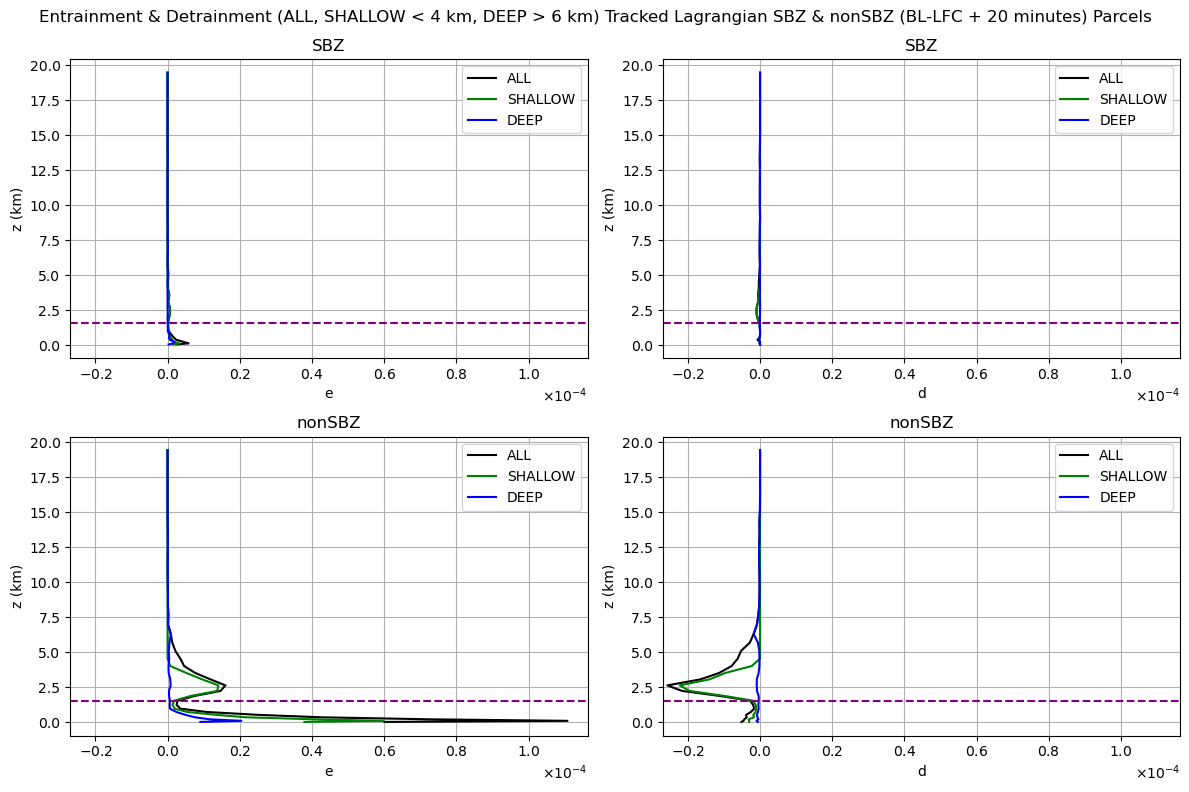

In [127]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

#MAKING DETRAINMENT VALUES POSITIVE
ALL_d[:,0]*=-1;SHALLOW_d[:,0]*=-1;DEEP_d[:,0]*=-1
nonSBZ_ALL_d[:,0]*=-1;nonSBZ_SHALLOW_d[:,0]*=-1;nonSBZ_DEEP_d[:,0]*=-1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (ALL_e, SHALLOW_e, DEEP_e, 'e', 'SBZ'),
    (ALL_d, SHALLOW_d, DEEP_d, 'd', 'SBZ'),
    (nonSBZ_ALL_e, nonSBZ_SHALLOW_e, nonSBZ_DEEP_e, 'e', 'nonSBZ'),
    (nonSBZ_ALL_d, nonSBZ_SHALLOW_d, nonSBZ_DEEP_d, 'd', 'nonSBZ'),
]

#MINMAX FOR XLIM
min_max_values = [(arr[:, 0].min(), arr[:, 0].max()) for arr, *_ in profiles]
min_max_values=[(min(val[0] for val in min_max_values)),(max(val[1] for val in min_max_values))]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
    globals()[f'ax{i+1}'] = fig.add_subplot(gs[i])  # Dynamically create ax1, ax2, ax3, ...
    ax = globals()[f'ax{i+1}']

    
    # # Compute the averaged profile
    # ALL_profile = averaged_profiles(ALL_profile_array)
    # SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    # DEEP_profile = averaged_profiles(DEEP_profile_array)
    ALL_profile=ALL_profile_array.copy()
    SHALLOW_profile=SHALLOW_profile_array.copy()
    DEEP_profile=DEEP_profile_array.copy()
    
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, -1],color='black',label='ALL')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1],color='green',label='SHALLOW')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1],color='blue',label='DEEP')
    ax.set_xlabel(xlabel)
    ax.set_title(CLlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    ax.legend()
# legend_ax = fig.add_subplot(gs[0, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)


#FIXING AXES
fix_x_limits([ax1,ax2,ax3,ax4])
fix_y_limits([ax1,ax2,ax3,ax4])

#ACCESSORIES
plt.suptitle('Entrainment & Detrainment (ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian SBZ & nonSBZ (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MEAN LFC
# axs = fig.get_axes()
# ax1, ax2, ax3, ax4= axs
# for axis in [ax1,ax2]:
#     axis.axhline(np.mean((mean_LFC(ALL_SBZ_out_nz),mean_LFC(SHALLOW_SBZ_out_nz),
#                           mean_LFC(DEEP_SBZ_out_nz))),color='blue',linestyle='dashed',linewidth=1.2)
# for axis in [ax3,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_nonSBZ_out_nz),mean_LFC(SHALLOW_nonSBZ_out_nz),
#                           mean_LFC(DEEP_nonSBZ_out_nz))),color='blue',linestyle='dashed',linewidth=1.2)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4= axs
for axis in [ax1,ax2,ax3,ax4]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4])

(-0.00011486995571637273, 0.0001211797728014045)
(-0.9395961281843483, 20.41351872170344)


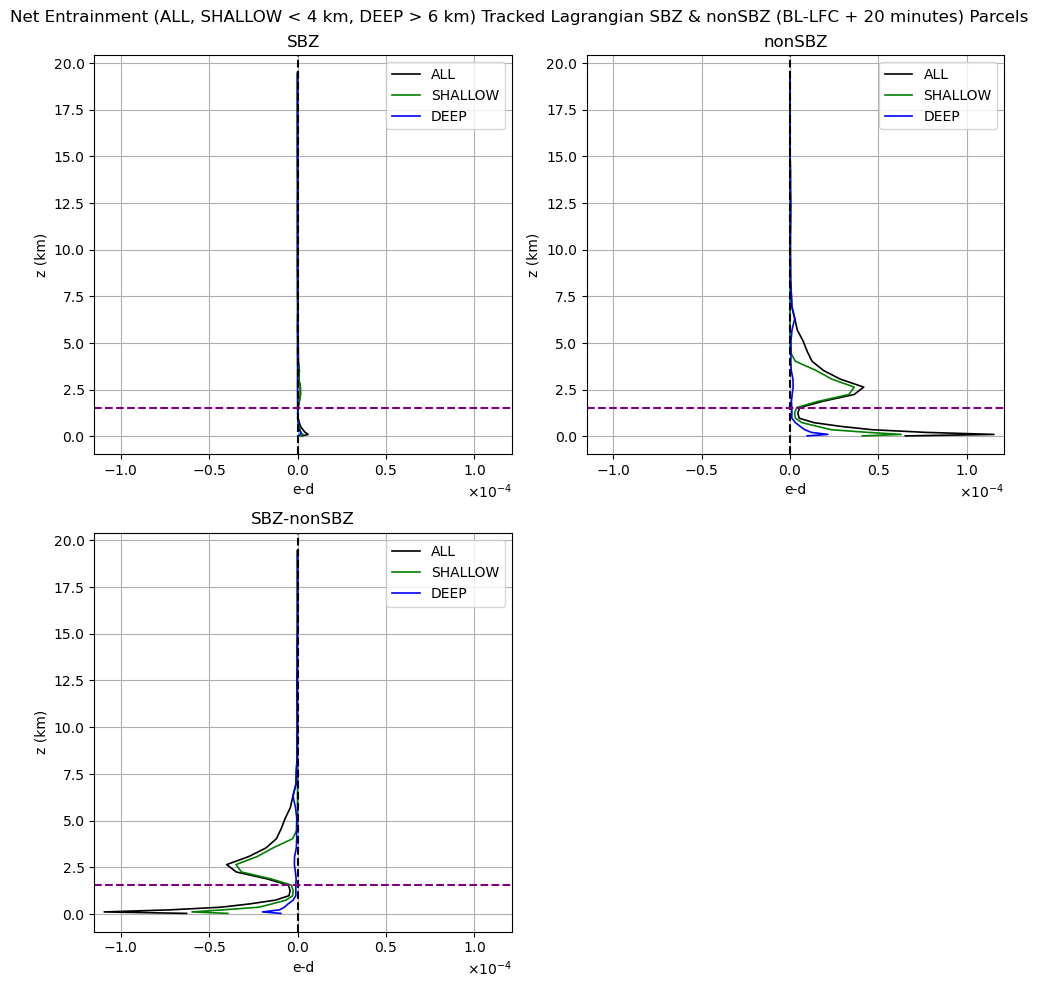

In [128]:
#NET ENTRAINMENT

xlims=[] #FIXING XAXIS
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# List of profile arrays and their corresponding labels and x-axis titles

ALL_net=ALL_e.copy(); ALL_net[:,0]-=ALL_d[:,0]
SHALLOW_net=SHALLOW_e.copy(); SHALLOW_net[:,0]-=SHALLOW_d[:,0]
DEEP_net=DEEP_e.copy(); DEEP_net[:,0]-=DEEP_d[:,0]

nonSBZ_ALL_net=nonSBZ_ALL_e.copy(); nonSBZ_ALL_net[:,0]-=nonSBZ_ALL_d[:,0]
nonSBZ_SHALLOW_net=nonSBZ_SHALLOW_e.copy(); nonSBZ_SHALLOW_net[:,0]-=nonSBZ_SHALLOW_d[:,0]
nonSBZ_DEEP_net=nonSBZ_DEEP_e.copy(); nonSBZ_DEEP_net[:,0]-=nonSBZ_DEEP_d[:,0]

ALL_SBZnonSBZ=ALL_net.copy(); ALL_SBZnonSBZ[:,0]-=nonSBZ_ALL_net[:,0]
SHALLOW_SBZnonSBZ=SHALLOW_net.copy(); SHALLOW_SBZnonSBZ[:,0]-=nonSBZ_SHALLOW_net[:,0]
DEEP_SBZnonSBZ=DEEP_net.copy(); DEEP_SBZnonSBZ[:,0]-=nonSBZ_DEEP_net[:,0]


profiles = [
    (ALL_net, SHALLOW_net, DEEP_net, 'e-d', 'SBZ'),
    (nonSBZ_ALL_net, nonSBZ_SHALLOW_net, nonSBZ_DEEP_net, 'e-d', 'nonSBZ'),
    (ALL_SBZnonSBZ, SHALLOW_SBZnonSBZ, DEEP_SBZnonSBZ, 'e-d', 'SBZ-nonSBZ')
]

#MINMAX FOR XLIM
min_max_values = [(arr[:, 0].min(), arr[:, 0].max()) for arr, *_ in profiles]
min_max_values=[(min(val[0] for val in min_max_values)),(max(val[1] for val in min_max_values))]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
    globals()[f'ax{i+1}'] = fig.add_subplot(gs[i])  # Dynamically create ax1, ax2, ax3, ...
    ax = globals()[f'ax{i+1}']

    
    # # Compute the averaged profile
    # ALL_profile = averaged_profiles(ALL_profile_array)
    # SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    # DEEP_profile = averaged_profiles(DEEP_profile_array)
    ALL_profile=ALL_profile_array.copy()
    SHALLOW_profile=SHALLOW_profile_array.copy()
    DEEP_profile=DEEP_profile_array.copy()
    
    
    # Plot the profile

    #linewidth
    if i == 2: 
        lw=1.2
    else: lw=1.2
        
    ax.plot(ALL_profile[:, 0], ALL_profile[:, -1],color='black',label='ALL',lw=lw)
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1],color='green',label='SHALLOW',lw=lw)
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1],color='blue',label='DEEP',lw=lw)

    ax.axvline(0,color='k',linestyle='dashed')
    ax.set_xlabel(xlabel)
    ax.set_title(CLlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)
    

#LEGEND
    ax.legend()
# legend_ax = fig.add_subplot(gs[0, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#FIXING AXES
fix_x_limits([ax1,ax2,ax3])
fix_y_limits([ax1,ax2,ax3])

#ACCESSORIES
plt.suptitle('Net Entrainment (ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian SBZ & nonSBZ (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MEAN LFC
# axs = fig.get_axes()
# ax1, ax2, ax3 = axs
# for axis in [ax1]:
#     axis.axhline(np.mean((mean_LFC(ALL_SBZ_out_nz),mean_LFC(SHALLOW_SBZ_out_nz),
#                           mean_LFC(DEEP_SBZ_out_nz))),color='blue',linestyle='dashed',linewidth=1.2)
# for axis in [ax2]:
#     axis.axhline(np.mean((mean_LFC(ALL_nonSBZ_out_nz),mean_LFC(SHALLOW_nonSBZ_out_nz),
#                           mean_LFC(DEEP_nonSBZ_out_nz))),color='blue',linestyle='dashed',linewidth=1.2)
# for axis in [ax3]:
#     axis.axhline(np.mean((mean_LFC(ALL_SBZ_out_nz),mean_LFC(SHALLOW_SBZ_out_nz),
#                           mean_LFC(DEEP_SBZ_out_nz),mean_LFC(ALL_nonSBZ_out_nz),mean_LFC(SHALLOW_nonSBZ_out_nz),
#                           mean_LFC(DEEP_nonSBZ_out_nz))),color='blue',linestyle='dashed',linewidth=1.2)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3 = axs
for axis in [ax1,ax2,ax3]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3 ])

In [ ]:
#RESIDENCE CODE
########################################################################################################################

In [ ]:
#READING DATA BACK IN LATER

In [4]:
with h5py.File(dir2+f'lagrangian_binary_threshold.h5', 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

In [361]:
#CALCULATING RESIDENCE TIMES
#############################

In [6]:
# B=np.array([0,1,0,1,0,1,1,0,0,1,1])

# # B=1-B #for detrainment, otherwise do comment out
# print(f'binary {B}')
# cat=np.concatenate(([0], B, [0]))
# # print(f'cat {cat}')
# diff=np.diff(cat)
# print(f'diff {diff}')

In [34]:
# #CODE FOR SUBSETTING DRY ENTRAINMENT
# ind=0

# row=out_nz[ind]
# out=residence_times(row[0],'e')
# where=np.where((out[5]<=3)&(out[5]!=-100000))

# A[out[1][where],row[0]] #set to 0 

array([1])

In [9]:
def residence_times(p,type):
    B = A[:,p]

    # B=np.array([0,1,0,1,0,0,1,1,0,1,1]) #TESTING
    
    T=np.arange(len(B))
    
    if np.any(B)==True:
        if type=='e':
            B=B.copy()
        elif type=='d':
            B=1-B
    
        
        # Find the changes in the array
        changes = np.diff(np.concatenate(([0], B, [0])))  # Add 0s to detect edges
            
        start_ind = np.where(changes == 1)[0]  # Start of sequences
        end_ind = np.where(changes == -1)[0]  # End of sequences
        
        # Calculate the lengths of sequences
        lengths = end_ind - start_ind

        sequences = [(start) for start, end, length in zip(start_ind, end_ind, lengths) if length >= 1] #only records en/detrainment time
        # sequences = [(start, *range(start + 1, end+1)) for start, end, length in zip(start_ind, end_ind, lengths) if length >= 1]
        lens=[(end-start) for start, end, length in zip(start_ind, end_ind, lengths) if length >= 1] #residence times

        #Remove the last one to get rid of entrainments that reach end of simulation
        sequences=sequences[:-1];lens=lens[:-1]

        #Initial Entrainment/Detrainment Times
        ts=np.array(sequences.copy()) #only records en/detrainment time 
        # ts=np.array(tuple(item for seq in sequences for item in seq))

         #Finds Last Time Parcel is in Cloudy Updraft before Inital Entrainment
        last=[None]+[np.where(B[:ind + 1] == 1)[0][-2] for ind in ts[1:]]
        last_lens=ts[1:]-last[1:]; last_lens=np.insert(last_lens, 0, -1e5)

        if np.any(ts):
            zs=Z[ts,p]
            ys=Y[ts,p]
            xs=X[ts,p]
            return [np.array(lens),ts,zs,ys,xs,last_lens]
        else:
            return []
    else:
        return []

p=42483; out=residence_times(p,type='e')
out


[array([2, 1, 1, 1, 1]),
 array([ 8, 11, 27, 31, 38]),
 array([ 8, 12, 15, 14, 14]),
 array([68, 68, 77, 81, 87]),
 array([348, 349, 364, 367, 373]),
 array([-100000,       2,      16,       4,       7])]

Text(0.5, 1.0, 'Testing')

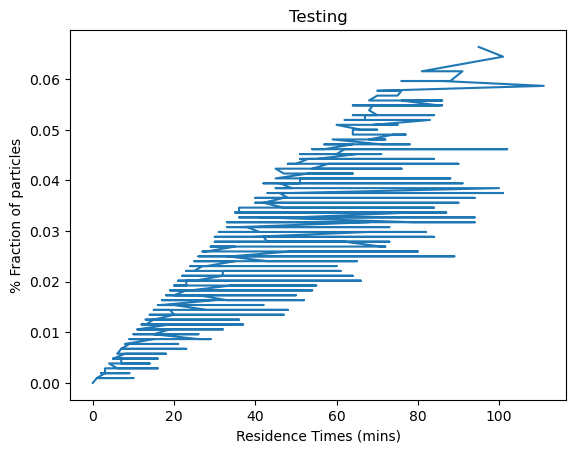

In [73]:
# #TORRI 2015 TESTING TESTING TESTING
# Nx=len(data['xh']);Ny=len(data['yh']);Nz=len(data['zh'])
# xy_array=np.zeros((Ny,Nx));xy_counter=np.zeros_like(xy_array)
# xz_array=np.zeros((Nz,Nx));xz_counter=np.zeros_like(xz_array)

# Np=125000-1
# for p in np.arange(Np): 
#     out=residence_times(p,type='e')
#     if np.any(out):
#         xy_array[out[3],out[4]]+=out[0] #add the (x,y) residence times 
#         xy_counter[out[3],out[4]]+=np.ones_like(out[0])
        
#         xz_array[out[2],out[4]]+=out[0] #add the (x,z) residence times 
#         xz_counter[out[2],out[4]]+=np.ones_like(out[0])


# one=xz_array.flatten()
# two=xz_counter.flatten()

# #SORTING
# sorted_indices = np.argsort(two)
# sorted_two = two[sorted_indices]
# sorted_one = one[sorted_indices]

# plt.plot(sorted_one,sorted_two*100/(np.sum(xz_counter)))
# plt.ylabel('% Fraction of particles');plt.xlabel('Residence Times (mins)')
# plt.title("Testing")

In [5]:
#ENTRAINMENT/DETRAINMENT PROFILES
Nx=len(data['xh']);Ny=len(data['yh']);Nz=len(data['zh'])
xy_array=np.zeros((Ny,Nx));xy_counter=np.zeros_like(xy_array)
xz_array=np.zeros((Nz,Nx));xz_counter=np.zeros_like(xz_array)

Np=125000-1
for p in np.arange(Np): 
    out=residence_times(p,type='e')
    

    if np.any(out):
        # #TESTING. ONLY STORING PRECONDITIONS PARCELS
        # for ind in np.arange(6):
        #     out[ind]=out[ind][np.where(out[-1]<=2)]
        # #####

        # xy_array[out[3],out[4]]+=out[0] #add the (x,y) residence times 
        # xy_counter[out[3],out[4]]+=np.ones_like(out[0])
        np.add.at(xy_array, (out[3], out[4]), out[0])  
        np.add.at(xy_counter, (out[3], out[4]), 1)
        
        # xz_array[out[2],out[4]]+=out[0] #add the (x,z) residence times 
        # xz_counter[out[2],out[4]]+=np.ones_like(out[0])
        np.add.at(xz_array, (out[2], out[4]), out[0])  # Add residence times to (x, z) positions
        np.add.at(xz_counter, (out[2], out[4]), 1)


#Divide by Counts
mask = xy_counter != 0
xy_array[mask]/=xy_counter[mask]
mask = xz_counter != 0
xz_array[mask]/=xz_counter[mask]

#Convert to Minutes
mins=((data['time'][1]-data['time'][0])/1e9/60).item()
xy_array*=mins
xz_array*=mins

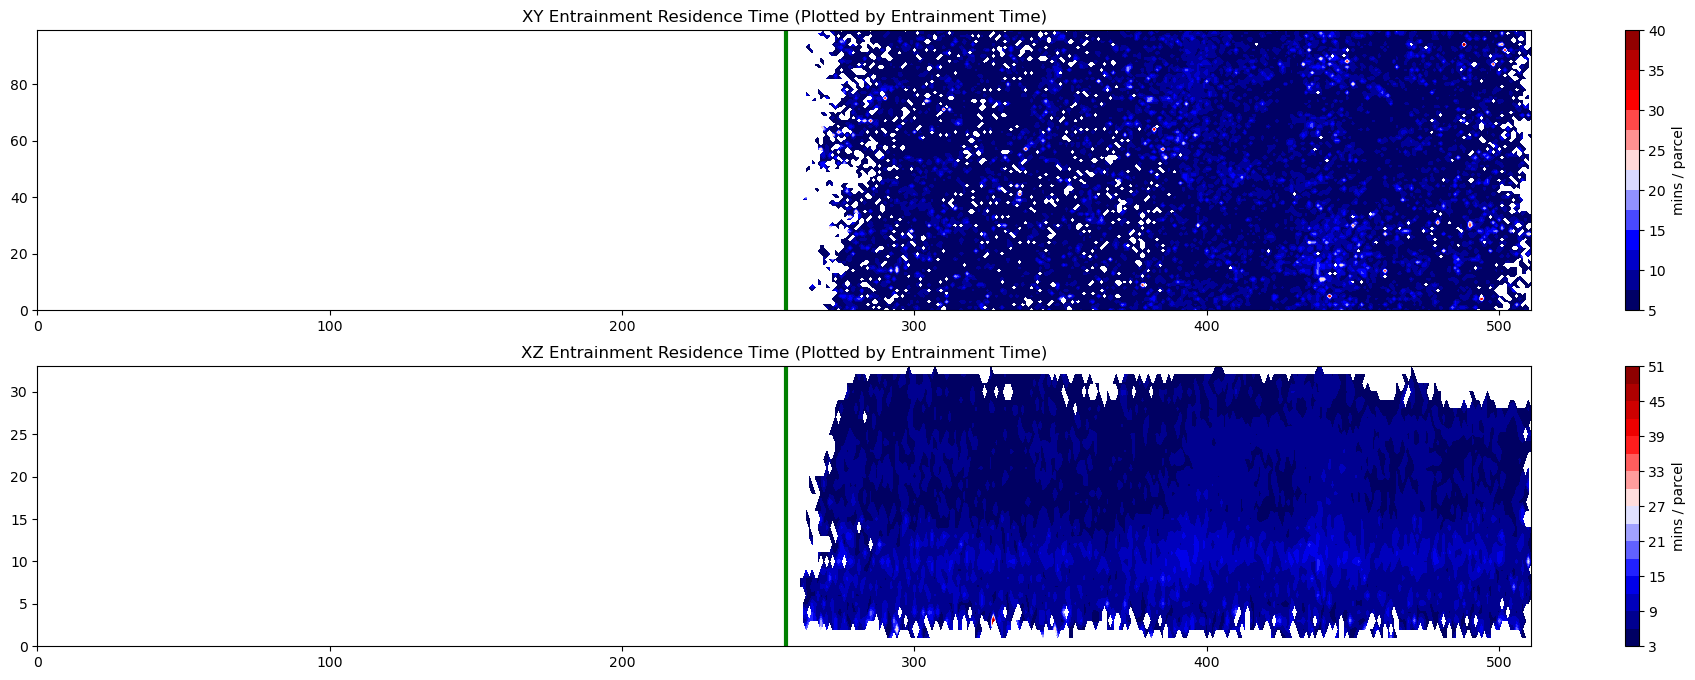

In [7]:
xy_array[xy_array==0]=np.nan
xz_array[xz_array==0]=np.nan

fig = plt.figure(figsize=(8*(512/34)/5, 8))
gs = gridspec.GridSpec(2, 1)  # 1 row, 2 columns
cmap='seismic'
levels1=15;levels2=15

# First subplot (xy_array contour)
ax1 = fig.add_subplot(gs[0, 0])  # First column
contour1 = ax1.contourf(xy_array,levels=levels1,cmap=cmap)
cbar1 = plt.colorbar(contour1, ax=ax1);cbar1.set_label("mins / parcel")
ax1.set_title("XY Entrainment Residence Time (Plotted by Entrainment Time)")

# Second subplot (xz_array contour)
ax2 = fig.add_subplot(gs[1, 0])  # Second column
contour2 = ax2.contourf(xz_array, levels=levels2, cmap=cmap)
cbar2 = plt.colorbar(contour2, ax=ax2);cbar2.set_label("mins / parcel")
ax2.set_title("XZ Entrainment Residence Time (Plotted by Entrainment Time)")


#COASTLINE
ax1.axvline(xy_array.shape[1]/2,color='green',linewidth=3)
ax2.axvline(xy_array.shape[1]/2,color='green',linewidth=3)

#THICKEN COLOR LINES

for edge in cbar1.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(10)
for edge in cbar2.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(8)



/tmp/ipykernel_2720098/1622528860.py:9: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')


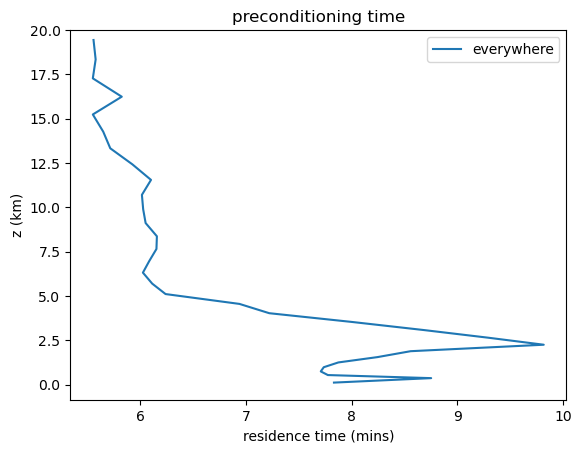

In [12]:
# currently i look for runs of being in cloudy updraft that are at least 5 minutes (1 timestep). i add the total length of that run at the location of initial entrainment/detrainment. then i average to get vertical profile. 

# For entrainment, particles should stay in a cloud for 30/60 minutes
# I’m very surprised by a) the extremely low values for entrainment time and b) the extremely high values for detainment times
# another thing: this is only cloudy updrafts, not clouds as well. is that 30/60 minutes true for the “cloud updrafts”?
# for detrainment then, there are some parcels that don’t interact with any “cloudy updrafts” for a very long time.
# also, if you look at the contour plot we do have higher values than the vertical profile 

plt.plot(np.nanmean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')
plt.ylabel('z (km)');plt.xlabel('residence time (mins)')


# plt.plot(np.nanmean(xz_array[:,int(512/2):512],axis=(1)),data['zh'],label='over land')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

# plt.plot(np.nanmean(xz_array[:,0:int(512/2)],axis=(1)),data['zh'],label='over ocean')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

plt.ylim(top=20)
plt.title('preconditioning time')
plt.legend()

In [25]:
#PRECONDITIONING TIMES
#ENTRAINMENT/DETRAINMENT PROFILES
Nx=len(data['xh']);Ny=len(data['yh']);Nz=len(data['zh'])
xy_array=np.zeros((Ny,Nx));xy_counter=np.zeros_like(xy_array)
xz_array=np.zeros((Nz,Nx));xz_counter=np.zeros_like(xz_array)

Np=125000-1
for p in np.arange(Np): 
# for p in out_nz[:,0]: #FOR OUT_NZ
    out=residence_times(p,type='e')
    

    if np.any(out):
        out=[arr[1:] for arr in out] #TESTING

        #TESTING. ONLY STORING PRECONDITIONS PARCELS
        # for ind in np.arange(6):
        #     out[ind]=out[ind][np.where(out[-1]<=2)]
        ######

        # xy_array[out[3],out[4]]+=out[0] #add the (x,y) residence times 
        # xy_counter[out[3],out[4]]+=np.ones_like(out[0])
        np.add.at(xy_array, (out[3], out[4]), out[-1])  
        np.add.at(xy_counter, (out[3], out[4]), 1)
        
        # xz_array[out[2],out[4]]+=out[0] #add the (x,z) residence times 
        # xz_counter[out[2],out[4]]+=np.ones_like(out[0])
        np.add.at(xz_array, (out[2], out[4]), out[-1])  # Add residence times to (x, z) positions
        np.add.at(xz_counter, (out[2], out[4]), 1)


#Divide by Counts
mask = xy_counter != 0
xy_array[mask]/=xy_counter[mask]
mask = xz_counter != 0
xz_array[mask]/=xz_counter[mask]

#Convert to Minutes
mins=((data['time'][1]-data['time'][0])/1e9/60).item()
xy_array*=mins
xz_array*=mins

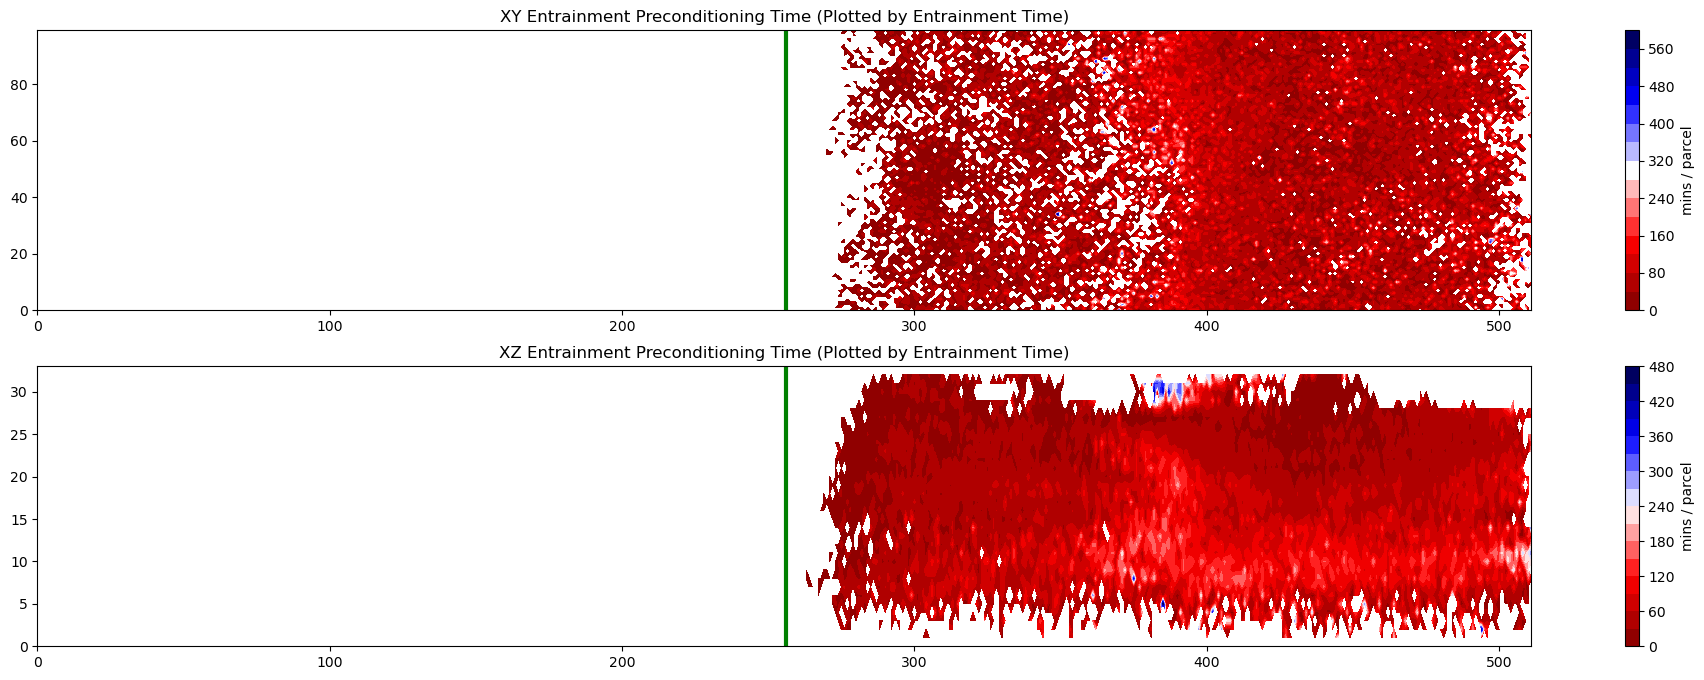

In [26]:
xy_array[xy_array==0]=np.nan
xz_array[xz_array==0]=np.nan

fig = plt.figure(figsize=(8*(512/34)/5, 8))
gs = gridspec.GridSpec(2, 1)  # 1 row, 2 columns
cmap='seismic_r'
levels1=15;levels2=15

# First subplot (xy_array contour)
ax1 = fig.add_subplot(gs[0, 0])  # First column
contour1 = ax1.contourf(xy_array,levels=levels1,cmap=cmap)
cbar1 = plt.colorbar(contour1, ax=ax1);cbar1.set_label("mins / parcel")
ax1.set_title("XY Entrainment Preconditioning Time (Plotted by Entrainment Time)")

# Second subplot (xz_array contour)
ax2 = fig.add_subplot(gs[1, 0])  # Second column
contour2 = ax2.contourf(xz_array, levels=levels2, cmap=cmap)
cbar2 = plt.colorbar(contour2, ax=ax2);cbar2.set_label("mins / parcel")
ax2.set_title("XZ Entrainment Preconditioning Time (Plotted by Entrainment Time)")


#COASTLINE
ax1.axvline(xy_array.shape[1]/2,color='green',linewidth=3)
ax2.axvline(xy_array.shape[1]/2,color='green',linewidth=3)

#THICKEN COLOR LINES

for edge in cbar1.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(10)
for edge in cbar2.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(8)



/tmp/ipykernel_2720098/956800355.py:9: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')


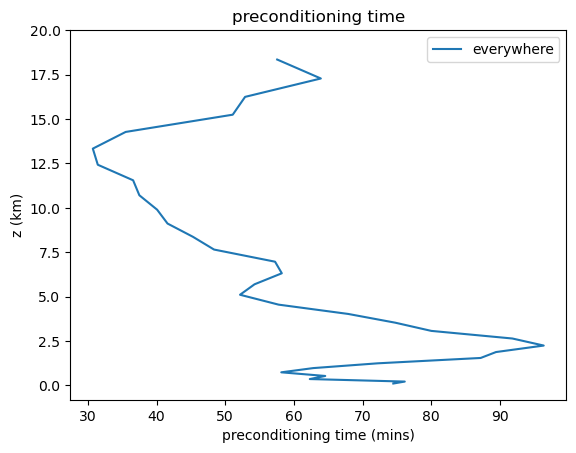

In [28]:
# currently i look for runs of being in cloudy updraft that are at least 5 minutes (1 timestep). i add the total length of that run at the location of initial entrainment/detrainment. then i average to get vertical profile. 

# For entrainment, particles should stay in a cloud for 30/60 minutes
# I’m very surprised by a) the extremely low values for entrainment time and b) the extremely high values for detainment times
# another thing: this is only cloudy updrafts, not clouds as well. is that 30/60 minutes true for the “cloud updrafts”?
# for detrainment then, there are some parcels that don’t interact with any “cloudy updrafts” for a very long time.
# also, if you look at the contour plot we do have higher values than the vertical profile 

plt.plot(np.nanmean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')
plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')


# plt.plot(np.nanmean(xz_array[:,int(512/2):512],axis=(1)),data['zh'],label='over land')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

# plt.plot(np.nanmean(xz_array[:,0:int(512/2)],axis=(1)),data['zh'],label='over ocean')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

plt.ylim(top=20)
plt.title('preconditioning time')
plt.legend()

In [365]:
# #TESTING TESTING TESTING *&*&*&*&
# #PRECONDITION FOR CL INTERACTION 


# #MAKE PROFILE ARRAY
# zhs=data['zh'].values
# profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
# profile_array[:,2]=zhs

# #COMPUTE
# mins=((data['time'][1]-data['time'][0])/1e9/60).item()
# for ind in np.arange(out_nz.shape[0]):
#     row=out_nz[ind]
    
#     previous=A[:,row[0]][:row[4]]
#     CL_z=Z[row[4],row[0]]
#     if np.any(previous)==True:
#         last=np.where(previous==1)[0][-1]
#         last_len=row[4]-last
#         last_len_mins=last_len*mins
        
#         #ADD TO PROFILE ARRAY
#         profile_array[CL_z,0]+=last_len*mins
#         profile_array[CL_z,1]+=1

    
#    #*&*&

# def averaged_profiles(profile): 
#     out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
#     out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
#     return out_var
# avg_profile_array=averaged_profiles(profile_array)

# plt.plot(avg_profile_array[:,0],avg_profile_array[:,1]*1000)
# plt.xlabel('t (mins)');plt.ylabel('z (m)')
# plt.title('Testing. When was parcel last in cloudy updraft before hitting CL')

In [19]:
Nx=len(data['xh']);Ny=len(data['yh']);Nz=len(data['zh'])
xy_array=np.zeros((Ny,Nx));xy_counter=np.zeros_like(xy_array)
xz_array=np.zeros((Nz,Nx));xz_counter=np.zeros_like(xz_array)

Np=125000-1
for p in np.arange(Np): 
    out=residence_times(p,type='d')
    if np.any(out):
        
        # xy_array[out[3],out[4]]+=out[0] #add the (x,y) residence times 
        # xy_counter[out[3],out[4]]+=np.ones_like(out[0])
        np.add.at(xy_array, (out[3], out[4]), out[0])  
        np.add.at(xy_counter, (out[3], out[4]), 1)
        
        # xz_array[out[2],out[4]]+=out[0] #add the (x,z) residence times 
        # xz_counter[out[2],out[4]]+=np.ones_like(out[0])
        np.add.at(xz_array, (out[2], out[4]), out[0])  # Add residence times to (x, z) positions
        np.add.at(xz_counter, (out[2], out[4]), 1)


#Divide by Counts
mask = xy_counter != 0
xy_array[mask]/=xy_counter[mask]
mask = xz_counter != 0
xz_array[mask]/=xz_counter[mask]


#Convert to Minutes
mins=((data['time'][1]-data['time'][0])/1e9/60).item()
xy_array*=mins
xz_array*=mins

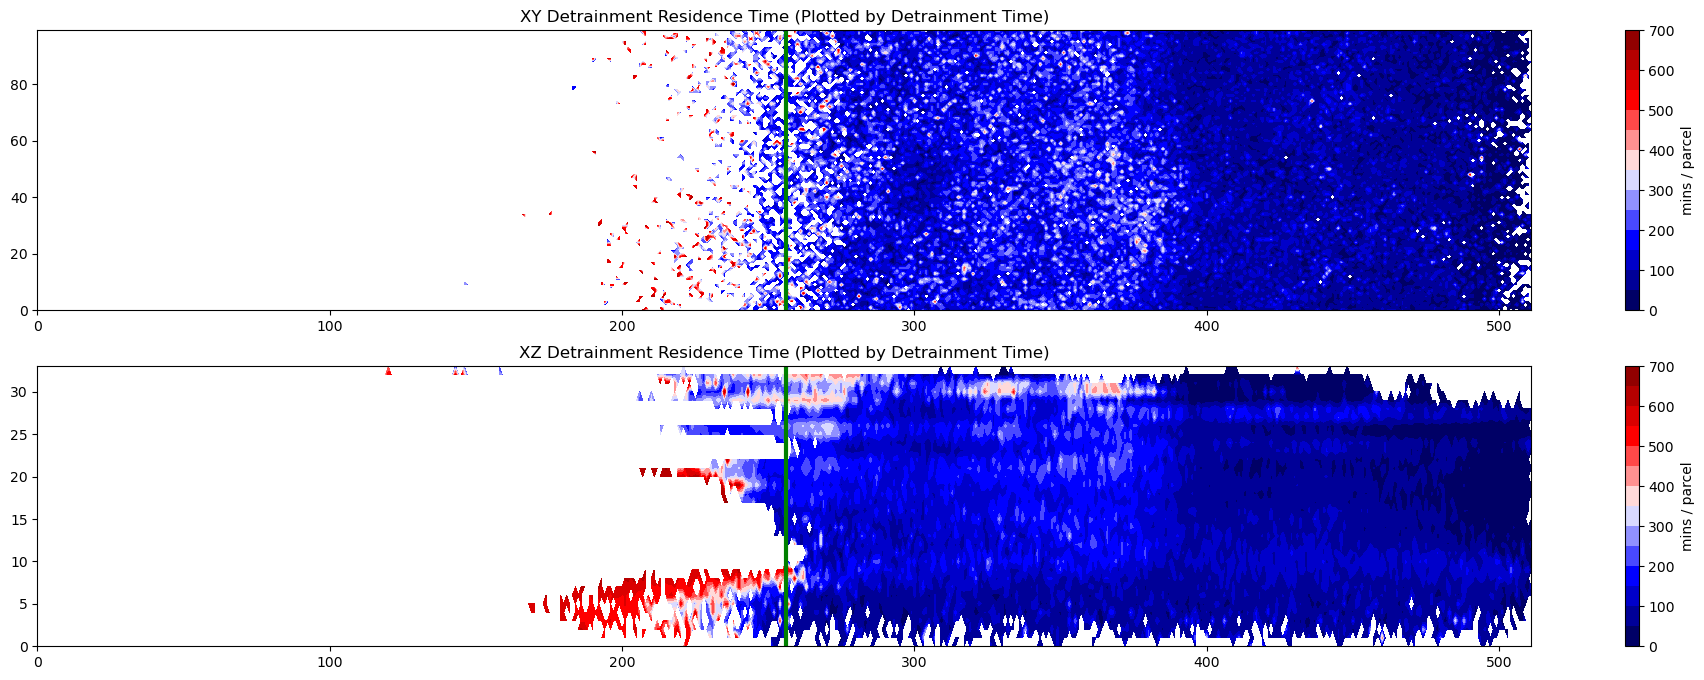

In [20]:
xy_array[xy_array==0]=np.nan
xz_array[xz_array==0]=np.nan

fig = plt.figure(figsize=(8*(512/34)/5, 8))
gs = gridspec.GridSpec(2, 1)  # 1 row, 2 columns
cmap='seismic'
levels1=15;levels2=15

# First subplot (xy_array contour)
ax1 = fig.add_subplot(gs[0, 0])  # First column
contour1 = ax1.contourf(xy_array,levels=levels1,cmap=cmap)
cbar1 = plt.colorbar(contour1, ax=ax1);cbar1.set_label("mins / parcel")
ax1.set_title("XY Detrainment Residence Time (Plotted by Detrainment Time)")

# Second subplot (xz_array contour)
ax2 = fig.add_subplot(gs[1, 0])  # Second column
contour2 = ax2.contourf(xz_array, levels=levels2, cmap=cmap)
cbar2 = plt.colorbar(contour2, ax=ax2);cbar2.set_label("mins / parcel")
ax2.set_title("XZ Detrainment Residence Time (Plotted by Detrainment Time)")


#COASTLINE
ax1.axvline(xy_array.shape[1]/2,color='green',linewidth=3)
ax2.axvline(xy_array.shape[1]/2,color='green',linewidth=3)

#THICKEN COLOR LINES

for edge in cbar1.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(10)
for edge in cbar2.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(8)



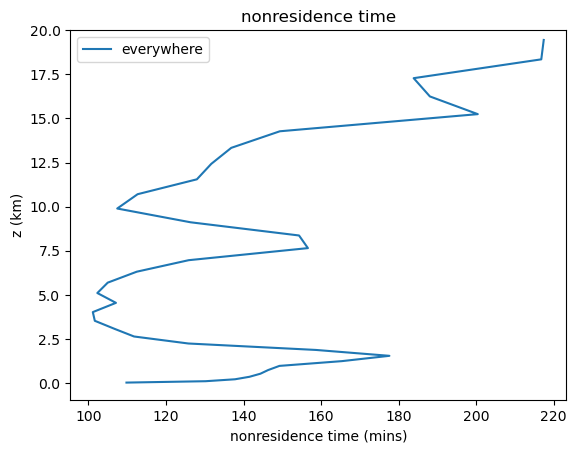

In [22]:
# currently i look for runs of being in cloudy updraft that are at least 5 minutes (1 timestep). i add the total length of that run at the location of initial entrainment/detrainment. then i average to get vertical profile. 

# For entrainment, particles should stay in a cloud for 30/60 minutes
# I’m very surprised by a) the extremely low values for entrainment time and b) the extremely high values for detainment times
# another thing: this is only cloudy updrafts, not clouds as well. is that 30/60 minutes true for the “cloud updrafts”?
# for detrainment then, there are some parcels that don’t interact with any “cloudy updrafts” for a very long time.
# also, if you look at the contour plot we do have higher values than the vertical profile 

plt.plot(np.nanmean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')
plt.ylabel('z (km)');plt.xlabel('nonresidence time (mins)')


# plt.plot(np.nanmean(xz_array[:,int(512/2):512],axis=(1)),data['zh'],label='over land')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

# plt.plot(np.nanmean(xz_array[:,0:int(512/2)],axis=(1)),data['zh'],label='over ocean')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

plt.ylim(top=20)
plt.title('nonresidence time')
plt.legend()

In [180]:
# Loading Important Variables
##############
if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    buoyancy_data=data['buoyancy'].data

    import h5py
    with h5py.File(dir + 'Variable_Calculation/' + 'theta_e'+f'_{res}'+'.h5', 'r') as f:
        theta_e_data = f['theta_e'][:]
    
    print('done')
    empty_like=True

loading neccessary variables
done


In [ ]:
#IMPORTANT FOR PLOTTING

# xticks/yticks
# xticks = plt.gca().get_xticks()
# new_labels = [str(int(tick * 5)) for tick in xticks]
# plt.gca().set_xticklabels(new_labels);

# cbar-ticks
# cbar_ticks = cbar.get_ticks()  # Get the current ticks
# new_ticks = [str(int(tick * 5)) for tick in cbar_ticks]  # Modify ticks (multiply by 5 and convert to string)
# cbar.set_ticks(cbar_ticks)  # Set the original ticks again to avoid resetting
# cbar.set_ticklabels(new_ticks)


#imshow
# plt.yticks(np.arange(Nz))
# new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
# plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)

In [ ]:
#MAKING 2D HISTOGRAM OF RESIDENCE TIME VS Z (COLOR: VARIABLE)

In [10]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

In [31]:
lst=[]
for p in np.arange(Np):
    out=residence_times(p,type='e')
    if np.any(out)==True:
        lens=out[0]
        lst.append(lens)
print(f'max entrainment time: {max(lst)}')

max entrainment time: [14]


In [198]:
Nz=len(data['zh'])
profile=np.zeros((Nz,18)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e')
    if np.any(out)==True:
        lens=out[0]
        # print(lens)
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        for ind,(z,l) in enumerate(zip(zs,lens)):
            profile[z,l]+=1

# #NORMALIZATION
row_averages = np.nansum(profile, axis=1)
mask = row_averages!=0
profile[mask] /= row_averages[mask,np.newaxis]


/tmp/ipykernel_567860/3155184634.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


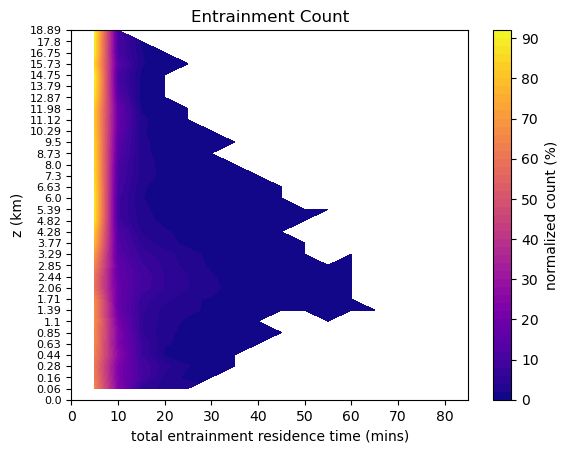

In [199]:
residence_profile=profile.copy() #save for comparing with TKE later


#Nan out zeros
cmap='plasma'
profile2=profile.copy()
profile2[profile2==0]=np.nan


#PLOTTING
# plt.imshow(profile.T);plt.gca().invert_yaxis()
plt.contourf(profile2*100,cmap=cmap,levels=50)

cbar=plt.colorbar(label='normalized count (%)')
plt.ylabel('z (km)');plt.xlabel('total entrainment residence time (mins)')
plt.title('Entrainment Count')

#FIXING TICKS

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);


In [95]:
with h5py.File(dir+f'lagrangian_binary_threshold.h5', 'r') as f:
    # Load the dataset by its name
    A = f['A'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

In [177]:
Nz=len(data['zh'])
profile=np.zeros((Nz,18)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e')
    if np.any(out)==True:
        lens=out[0]
        # print(lens)
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        
        for ind,(z,l) in enumerate(zip(zs,lens)):
            profile[z,l]+=w_data[ts[ind],zs[ind],ys[ind],xs[ind]]
            counter[z,l]+=1

#averaging by number of parcel
mask=profile!=0
profile[mask]/=counter[mask]

/tmp/ipykernel_567860/12529725.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


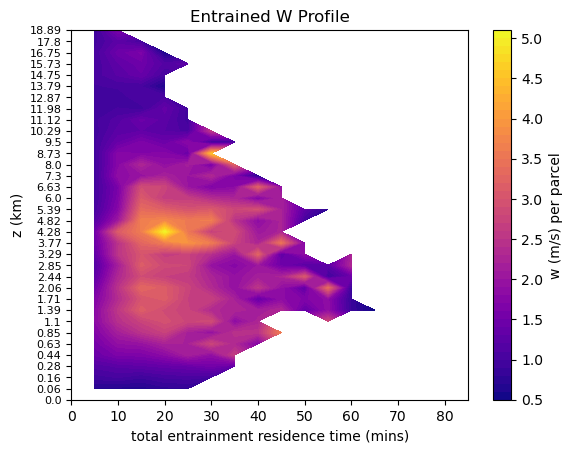

In [178]:
cmap='plasma'
profile[profile==0]=np.nan
plt.contourf(profile,cmap=cmap,levels=50)
plt.colorbar(label='w (m/s) per parcel')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title('Entrained W Profile')

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);


plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);

In [181]:
Nz=len(data['zh'])
profile=np.zeros((Nz,18)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e')
    if np.any(out)==True:
        lens=out[0]
        # print(lens)
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        
        for ind,(z,l) in enumerate(zip(zs,lens)):
            profile[z,l]+=theta_e_data[ts[ind],zs[ind],ys[ind],xs[ind]]
            counter[z,l]+=1

#averaging by number of parcel
mask=profile!=0
profile[mask]/=counter[mask]

/tmp/ipykernel_567860/3886817416.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


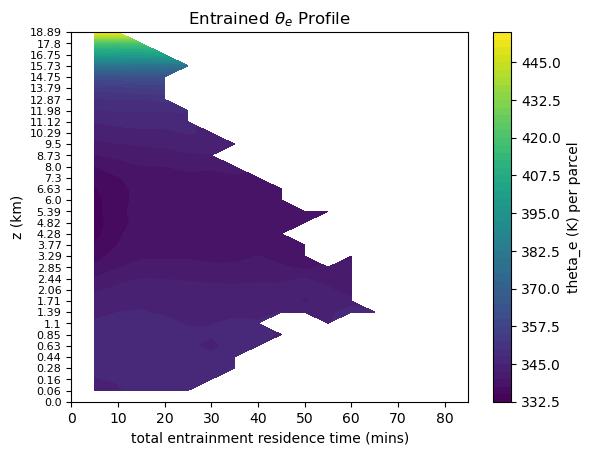

In [186]:
cmap='viridis'
profile[profile==0]=np.nan

plt.contourf(profile,cmap=cmap,levels=50)#,vmin=200)
plt.colorbar(label='theta_e (K) per parcel')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title(r'Entrained $\theta_e$ Profile')

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);


In [187]:
#Loading Some Data
tke_data=data['tke'].interp(zf=data['zh']).data

In [194]:
Nz=len(data['zh'])
profile=np.zeros((Nz,18)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e')
    if np.any(out)==True:
        lens=out[0]
        # print(lens)
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        
        for ind,(z,l) in enumerate(zip(zs,lens)):
            profile[z,l]+=tke_data[ts[ind],zs[ind],ys[ind],xs[ind]]
            counter[z,l]+=1

#averaging by number of parcel
mask=profile!=0
profile[mask]/=counter[mask]

/tmp/ipykernel_567860/480028002.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


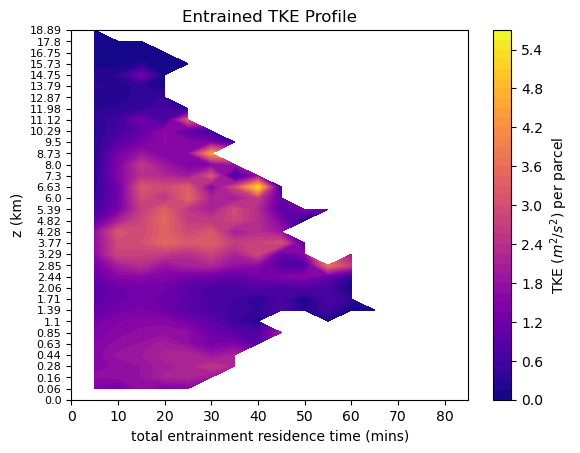

In [195]:
TKE_profile=profile.copy()

cmap='plasma'
profile[profile==0]=np.nan

plt.contourf(profile,cmap=cmap, levels=50)
plt.colorbar(label=r'TKE ($m^2/s^2$) per parcel')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title('Entrained TKE Profile')

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);

/tmp/ipykernel_567860/1324642050.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


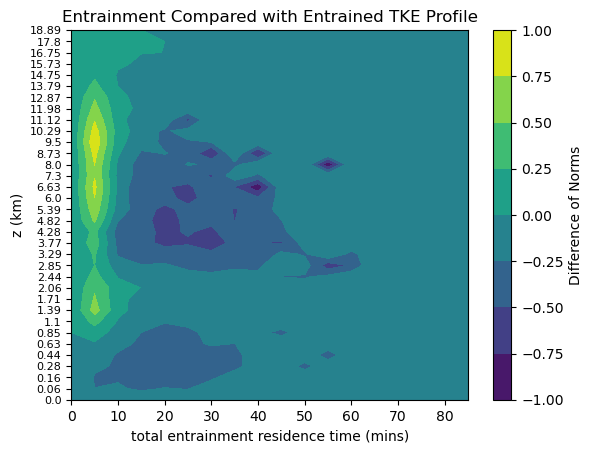

In [197]:
#TESTING TESTING TESTING


TKE_norm = (TKE_profile - np.min(TKE_profile)) / (np.max(TKE_profile) - np.min(TKE_profile))
residence_norm = (residence_profile - np.min(residence_profile)) / (np.max(residence_profile) - np.min(residence_profile))

compare_array = (1-TKE_norm) - (1-residence_norm)



plt.contourf(compare_array)
plt.colorbar(label='Difference of Norms')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title('Entrainment Compared with Entrained TKE Profile')

####

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);